# Лабораторная работа 9. Рекуррентные сети и трансформеры: архитектуры для последовательностей и текста

**Курс:** Машинное обучение. Безопасность ИИ-систем

**По материалам лекции 7**


**Вариант / seed:** вариант 1: `SEED = 42`, `D_MODEL = 64`, `N_MAX = 12`, `D_CELL = 48`, температуры 0.5 / 1.0 / 1.5


### Таблица вариантов

| Вариант | `SEED` | `D_MODEL` | `N_MAX` (пар в обучении) | `D_CELL` | Температуры для части H |
|---|---|---|---|---|---|
| 1 | 42 | 64 | 12 | 48 | 0.5 / 1.0 / 1.5 |
| 2 | 7 | 48 | 10 | 40 | 0.4 / 1.0 / 1.6 |
| 3 | 123 | 64 | 8 | 48 | 0.6 / 1.0 / 1.4 |
| 4 | 2024 | 56 | 12 | 56 | 0.5 / 1.2 / 1.8 |
| 5 | 314 | 48 | 8 | 40 | 0.7 / 1.0 / 1.3 |
| 6 | 555 | 64 | 10 | 56 | 0.5 / 0.9 / 1.7 |

> Вариант выдаёт преподаватель. Все числа в отчёте должны соответствовать **вашему** варианту,
> а не значениям из примера в тексте.

### Цель работы

Экспериментально установить, чем механизм внимания отличается от рекуррентного накопления состояния,
какой ценой достигается каждое из свойств (точность вспоминания, стоимость контекста, память при
генерации), и какие архитектурные свойства становятся поверхностью атаки на языковые модели.

### Задачи

1. Реализовать BPE-токенизацию и оценить влияние уровня токенизации на длину последовательности.
2. Измерить затухание градиента в рекуррентной сети и сравнить мультипликативный путь с аддитивным.
3. Реализовать масштабированное скалярное внимание с каузальной маской.
4. Проверить численно, что RoPE зависит только от разности позиций, и построить штраф ALiBi.
5. Обучить двухслойный мини-трансформер задаче ассоциативного вспоминания и найти индукционную голову.
6. Реализовать линейное внимание в рекуррентной форме и сравнить его с softmax-вниманием.
7. Сделать рекуррентную ячейку избирательной и проверить, что это даёт управляемую память.
8. Реализовать top-k и top-p отсечение и оценить статистику многих попыток генерации.

### Порядок выполнения

1. Выполните ячейку настройки среды и впишите параметры своего варианта.
2. Идите по частям A–H подряд, заполняя каждый блок `TODO`.
3. После каждой части ответьте на вопрос в конце этой части (ячейка Markdown «Ответ»).
4. Заполните таблицы отчёта и сформулируйте выводы.
5. Перед сдачей выполните Kernel → Restart & Run All и убедитесь, что ошибок нет.

### Ограничение по безопасности

Работа не содержит и не должна содержать кода атак на реальные языковые модели и сервисы,
готовых строк обхода ограничений или инструментов автоматического подбора вредоносных запросов.
Часть H исследует **статистику выборки и архитектурные предпосылки** уязвимостей на игрушечной
модели — этого достаточно для понимания следующей лекции.

In [ ]:
# Настройка окружения и единый стиль рисунков
import math, time, warnings
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import torch
import torch.nn as nn
import torch.nn.functional as F

warnings.filterwarnings("ignore")
torch.set_num_threads(2)

PALETTE = {"attn": "#2E86AB", "linear": "#F2A541", "bad": "#D6455F",
           "good": "#3FA46A", "accent": "#7B4FA0", "gray": "#8A94A6"}
CMAP_HEAT = LinearSegmentedColormap.from_list(
    "heat7", ["#0B1D33", "#2E86AB", "#F2E8CF", "#F2A541", "#D6455F"])

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "font.size": 10.5,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.labelsize": 10.5,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linestyle": "--",
    "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
})

def finish(fig, title=None):
    if title:
        fig.suptitle(title, fontsize=13, fontweight="bold", y=0.995)
    fig.tight_layout(rect=(0, 0, 1, 0.96 if title else 1.0))
    plt.show()

print("torch:", torch.__version__, "| потоков:", torch.get_num_threads())

torch: 2.4.1+cu121 | потоков: 2


In [ ]:
# Параметры варианта 1
SEED    = 42
D_MODEL = 64
N_MAX   = 12
D_CELL  = 48
TAUS    = (0.5, 1.0, 1.5)

np.random.seed(SEED)
torch.manual_seed(SEED)
print("вариант: SEED=%d, D_MODEL=%d, N_MAX=%d, D_CELL=%d, TAUS=%s"
      % (SEED, D_MODEL, N_MAX, D_CELL, str(TAUS)))

вариант: SEED=42, D_MODEL=64, N_MAX=12, D_CELL=48, TAUS=(0.5, 1.0, 1.5)


## Часть A. Токенизация: BPE с нуля

Модель работает не с буквами и не со словами, а с токенами. Уровень токенизации задаёт длину
последовательности $n$, а значит и стоимость внимания $O(n^2)$, а также распределение частот:
редкие токены остаются недообученными.

**Задание A.1.** Реализуйте один шаг BPE: подсчёт частот пар соседних символов и слияние самой
частой пары.
**Задание A.2.** Обучите BPE на корпусе и измерьте коэффициенты сжатия «символы → BPE» и
«BPE → слова».
**Задание A.3.** Постройте график длины корпуса в токенах от числа выполненных слияний и
распределение частот токенов в логарифмических осях; отметьте порог редких токенов
`RARE_THR` (частота не выше `RARE_THR` за весь корпус).

In [ ]:
CORPUS = (
    "внимание позволяет модели обращаться к любой позиции последовательности напрямую. "
    "рекуррентная сеть накапливает состояние и постепенно теряет информацию о далёком прошлом. "
    "трансформер обучается параллельно по всем позициям и потому масштабируется. "
    "позиционное кодирование сообщает модели порядок токенов. "
    "линейное внимание заменяет матрицу внимания рекуррентным состоянием. "
    "избирательная рекуррентность делает затухание зависящим от входа. "
    "квантование и кэширование уменьшают стоимость генерации. "
) * 6

words = CORPUS.split()
vocab_words = {}
for w in words:
    key = tuple(w) + ("</w>",)
    vocab_words[key] = vocab_words.get(key, 0) + 1

def pair_counts(vocab):
    """{пара соседних символов: суммарная частота}; вес пары = частота слова."""
    counts = {}
    for seq, freq in vocab.items():
        for a, b in zip(seq[:-1], seq[1:]):
            counts[(a, b)] = counts.get((a, b), 0) + freq
    return counts

def merge_pair(vocab, pair):
    """Новый словарь, в котором все вхождения pair склеены в один символ."""
    a, b = pair
    merged = a + b
    new_vocab = {}
    for seq, freq in vocab.items():
        out, i = [], 0
        while i < len(seq):
            if i < len(seq) - 1 and seq[i] == a and seq[i + 1] == b:
                out.append(merged); i += 2
            else:
                out.append(seq[i]); i += 1
        key = tuple(out)
        new_vocab[key] = new_vocab.get(key, 0) + freq
    return new_vocab

print("слов в корпусе:", len(words), "| уникальных словоформ:", len(vocab_words))

слов в корпусе: 330 | уникальных словоформ: 51


In [ ]:
N_MERGES = 120
vocab = dict(vocab_words)
lengths, merges = [], []

def corpus_len(v):
    return sum(len(seq) * freq for seq, freq in v.items())

lengths.append(corpus_len(vocab))                  # длина до слияний (посимвольно + </w>)
for step in range(N_MERGES):
    counts = pair_counts(vocab)
    if not counts:
        break
    best = max(counts, key=counts.get)
    vocab = merge_pair(vocab, best)
    merges.append(best)
    lengths.append(corpus_len(vocab))

n_chars = len(CORPUS.replace(" ", ""))
n_bpe = lengths[-1]
token_freq = {}
for seq, freq in vocab.items():
    for tok in seq:
        token_freq[tok] = token_freq.get(tok, 0) + freq

print(f"выполнено слияний: {len(merges)}")
print(f"символов (без пробелов): {n_chars} | BPE-токенов: {n_bpe} | слов: {len(words)}")
print(f"сжатие «символы → BPE»: {n_chars / n_bpe:.2f}×")
print(f"отношение «BPE → слова»: {n_bpe / len(words):.2f} токена на слово")
print(f"размер словаря токенов: {len(token_freq)}")
print("первые 10 слияний:", ["".join(m) for m in merges[:10]])

выполнено слияний: 120
символов (без пробелов): 2652 | BPE-токенов: 1152 | слов: 330
сжатие «символы → BPE»: 2.30×
отношение «BPE → слова»: 3.49 токена на слово
размер словаря токенов: 92
первые 10 слияний: ['ни', 'е</w>', 'по', 'ет', 'ен', 'ани', 'и</w>', 'ст', '.</w>', 'ание</w>']


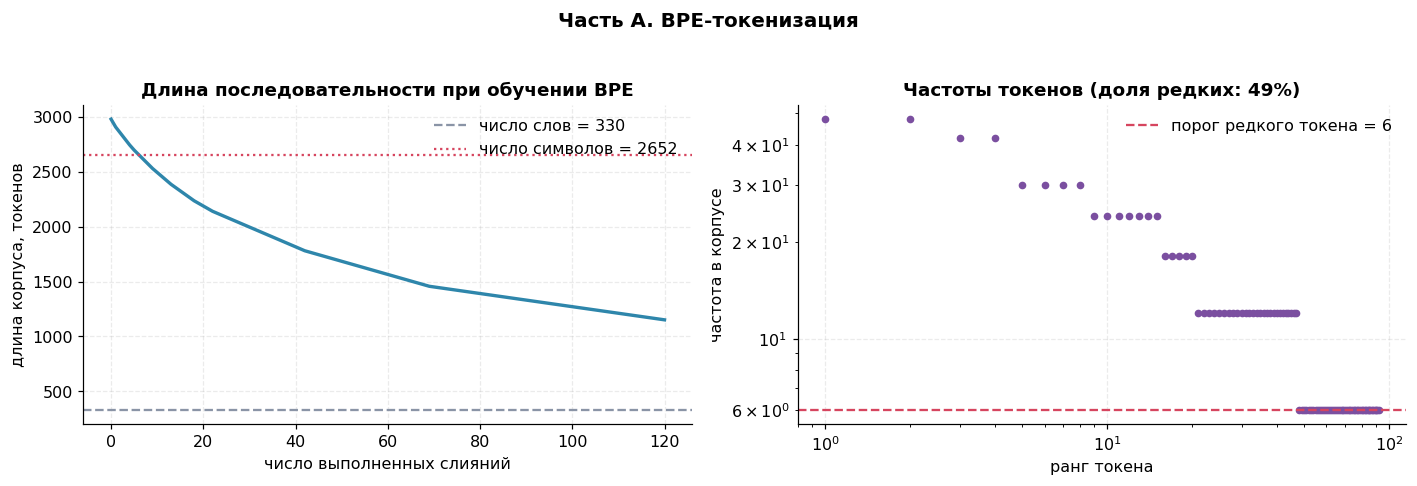

доля редких токенов (частота ≤ 6): 0.489
рост стоимости внимания при переходе к посимвольной токенизации: (2.30)² = 5.3×


In [ ]:
RARE_THR = 6
freqs = np.array(sorted(token_freq.values(), reverse=True))
rare_share = float(np.mean(freqs <= RARE_THR))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
axes[0].plot(range(len(lengths)), lengths, color=PALETTE["attn"], lw=2.2)
axes[0].axhline(len(words), ls="--", color=PALETTE["gray"], label=f"число слов = {len(words)}")
axes[0].axhline(n_chars, ls=":", color=PALETTE["bad"], label=f"число символов = {n_chars}")
axes[0].set_xlabel("число выполненных слияний"); axes[0].set_ylabel("длина корпуса, токенов")
axes[0].set_title("Длина последовательности при обучении BPE"); axes[0].legend()

ranks = np.arange(1, len(freqs) + 1)
axes[1].loglog(ranks, freqs, "o", ms=4, color=PALETTE["accent"])
axes[1].axhline(RARE_THR, ls="--", color=PALETTE["bad"], label=f"порог редкого токена = {RARE_THR}")
axes[1].set_xlabel("ранг токена"); axes[1].set_ylabel("частота в корпусе")
axes[1].set_title(f"Частоты токенов (доля редких: {rare_share:.0%})"); axes[1].legend()
finish(fig, "Часть A. BPE-токенизация")
print(f"доля редких токенов (частота ≤ {RARE_THR}): {rare_share:.3f}")
print(f"рост стоимости внимания при переходе к посимвольной токенизации: ({n_chars / n_bpe:.2f})² = {(n_chars / n_bpe) ** 2:.1f}×")

**Вопрос A.** Во сколько раз выросла бы стоимость слоя внимания при переходе от BPE к посимвольной токенизации?

**Ответ A.** После 120 слияний корпус из 2652 символов (без пробелов) кодируется 1152 BPE-токенами — сжатие **2.30×**. При посимвольной токенизации длина последовательности $n$ выросла бы в 2.30 раза, а стоимость слоя внимания, пропорциональная $n^2$, — в $2.30^2 \approx$ **5.3 раза**. Память под матрицу внимания растёт так же, KV-кэш при генерации — линейно, в 2.3 раза.

Обратная сторона видна на графике частот: из 92 токенов словаря **48.9 %** встречаются не чаще 6 раз за весь корпус (то есть в одной словоформе на каждое из шести повторений текста). Чем крупнее токены, тем короче последовательность, но тем больше редких токенов, эмбеддинги которых получают мало обучающего сигнала. Выбор размера словаря — компромисс между стоимостью внимания и недообученностью редких токенов.

## Часть B. Затухание градиента в рекуррентной сети

Для рекуррентности $h_t = \phi(W h_{t-1} + U x_t)$ производная по состоянию, удалённому на $k$ шагов,
содержит произведение $k$ матриц:

$
\frac{\partial h_T}{\partial h_{T-k}} = \prod_{j=0}^{k-1} \operatorname{diag}(\phi')\, W .
$

Норма такого произведения ведёт себя как $\rho(W)^k$. Аддитивный путь с гейтом $f_t$ даёт вместо
этого множитель $\prod f_t$, который при $f_t \to 1$ почти не затухает.

**Задание B.1.** Вычислите норму произведения $k$ матриц с заданным спектральным радиусом.
**Задание B.2.** Постройте график нормы от $k$ для $\rho \in \{0.9, 1.0, 1.2\}$ и добавьте
аддитивные пути с $f_t = 0.99$ и $f_t = 0.95$.
**Задание B.3.** Найдите эффективный горизонт памяти: при каком $k$ норма падает ниже $10^{-6}$.

In [ ]:
def make_W(d, rho, gen):
    # матрица со заданным спектральным радиусом
    A = gen.normal(size=(d, d)) / np.sqrt(d)
    return A * rho / np.max(np.abs(np.linalg.eigvals(A)))

def grad_norms(rho, k_max=120, d=32, seed=0):
    gen = np.random.default_rng(seed)
    W = make_W(d, rho, gen)
    P = np.eye(d)
    norms = []
    for _ in range(k_max):
        P = P @ W
        norms.append(np.linalg.norm(P, 2))
    return np.array(norms)

def horizon(rho, thr=1e-6, k_max=4000, d=32, seed=0):
    if rho >= 1.0:
        return np.inf                      # норма не падает: горизонта затухания нет
    k = int(np.ceil(np.log(thr) / np.log(rho)))
    return k if k <= k_max else np.inf

print("подсказка: rho ** k = thr  ->  k = log(thr) / log(rho)")

подсказка: rho ** k = thr  ->  k = log(thr) / log(rho)


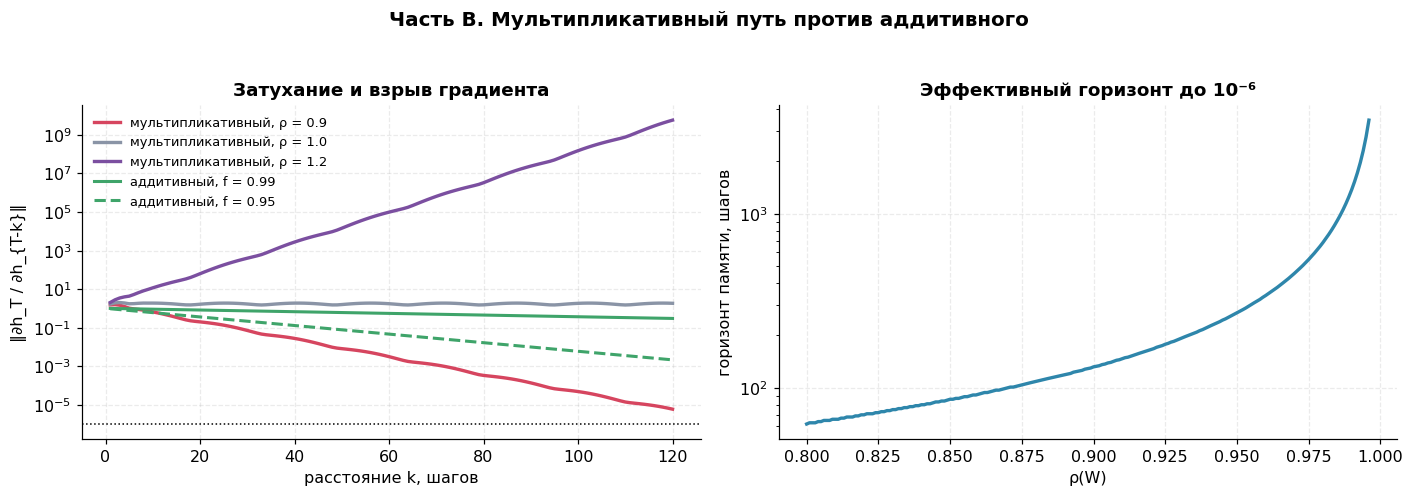

путь             норма при k=100    горизонт до 1e-6
ρ = 0.9                4.822e-05                 132
ρ = 1.0                1.816e+00                 inf
ρ = 1.2                1.504e+08                 inf
f = 0.99               3.660e-01                1375
f = 0.95               5.921e-03                 270

гейт, удерживающий сигнал ≥ 0.1 на 500 шагах: f ≥ 0.99541


In [ ]:
K_MAX = 120
ks = np.arange(1, K_MAX + 1)
norms = {rho: grad_norms(rho, K_MAX) for rho in (0.9, 1.0, 1.2)}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
cols = {0.9: PALETTE["bad"], 1.0: PALETTE["gray"], 1.2: PALETTE["accent"]}
for rho, nv in norms.items():
    axes[0].semilogy(ks, nv, color=cols[rho], lw=2.2, label=f"мультипликативный, ρ = {rho}")
for f, ls in ((0.99, "-"), (0.95, "--")):
    axes[0].semilogy(ks, f ** ks, ls=ls, color=PALETTE["good"], lw=2, label=f"аддитивный, f = {f}")
axes[0].axhline(1e-6, ls=":", color="k", lw=1)
axes[0].set_xlabel("расстояние k, шагов"); axes[0].set_ylabel("‖∂h_T / ∂h_{T-k}‖")
axes[0].set_title("Затухание и взрыв градиента"); axes[0].legend(fontsize=8.5)

rhos = np.linspace(0.8, 0.999, 200)
hs = [horizon(r) for r in rhos]
axes[1].semilogy(rhos, hs, color=PALETTE["attn"], lw=2.2)
axes[1].set_xlabel("ρ(W)"); axes[1].set_ylabel("горизонт памяти, шагов")
axes[1].set_title("Эффективный горизонт до 10⁻⁶")
finish(fig, "Часть B. Мультипликативный путь против аддитивного")

print(f"{'путь':<14}{'норма при k=100':>18}{'горизонт до 1e-6':>20}")
for rho in (0.9, 1.0, 1.2):
    print(f"ρ = {rho:<10}{norms[rho][99]:>18.3e}{str(horizon(rho)):>20}")
print(f"{'f = 0.99':<14}{0.99 ** 100:>18.3e}{str(horizon(0.99)):>20}")
print(f"{'f = 0.95':<14}{0.95 ** 100:>18.3e}{str(horizon(0.95)):>20}")
f_req = 0.1 ** (1 / 500)
print(f"\nгейт, удерживающий сигнал ≥ 0.1 на 500 шагах: f ≥ {f_req:.5f}")

ρ(W) — спектральный радиус: наибольший по модулю «коэффициент растяжения» матрицы. Как с процентами по вкладу: 0,9 в сотой степени — почти ноль, 1,2 в сотой степени — огромное число.
Аддитивный путь (идея LSTM и GRU): состояние не умножается на матрицу, а переносится почти без изменений с множителем-гейтом f_t, который сеть вычисляет сама.

**Вопрос B.** Какой гейт нужен, чтобы удерживать зависимость длиной 500 шагов с ослаблением не более чем в 10 раз? Сравните с $\rho(W)$.

**Ответ B.** Нужно $f^{500} \ge 0.1$, откуда $f \ge 0.1^{1/500} = e^{\ln 0.1 / 500} \approx$ **0.99541**. Формально для чистой рекуррентности получается то же требование $\rho(W) \ge 0.9954$, но выполнить его там практически невозможно:

1. **Лезвие ножа.** Множитель $\rho^k$ экспоненциален в обе стороны. По таблице 2: при $\rho = 0.9$ норма на расстоянии 100 шагов уже $4.8\cdot10^{-5}$ (горизонт до $10^{-6}$ — 132 шага), при $\rho = 1.2$ — взрыв до $1.5\cdot10^{8}$. Удерживать $\rho$ в узком окне $[0.9954; 1]$ в процессе обучения, когда $W$ меняется на каждом шаге, крайне трудно.
2. **Производная нелинейности.** В реальной сети произведение содержит $\operatorname{diag}(\phi')$, а для tanh $|\phi'| \le 1$ и обычно заметно меньше единицы. Эффективный множитель на шаг меньше $\rho(W)$, и для компенсации пришлось бы брать $\rho > 1$, приближаясь к взрыву.
3. **Одна матрица для всех шагов.** $W$ не зависит от входа, поэтому нельзя «держать» один сигнал и «забывать» другой.

Аддитивный путь с гейтом (LSTM, GRU) решает все три проблемы: множитель $\prod f_t$ не содержит производной нелинейности и матрицы, при $f_t \to 1$ он просто не затухает (при $f = 0.99$ норма на 100 шагах 0.366, горизонт 1375 шагов против 132 у $\rho = 0.9$), и гейт вычисляется по входу.

## Часть C. Внимание с нуля и роль масштабирования

$
\operatorname{Attention}(Q,K,V) = \operatorname{softmax}\!\left(\frac{QK^{\top}}{\sqrt{d_k}}\right) V .
$

Делитель $\sqrt{d_k}$ не косметика: при $q,k \sim \mathcal N(0,1)$ скалярное произведение имеет
дисперсию $d_k$, и без нормировки softmax при больших $d_k$ вырождается почти в one-hot, что
обнуляет градиент по ключам.

**Задание C.1.** Реализуйте одну голову внимания с каузальной маской и без неё.
**Задание C.2.** Проверьте два обязательных свойства: строки матрицы внимания суммируются в единицу,
а при каузальной маске верхний треугольник строго нулевой.
**Задание C.3.** Измерьте среднюю энтропию распределения внимания как функцию $d_k$ с делителем и
без него, постройте рисунок с картами внимания и графиком энтропии.

In [ ]:
def attention(Q, K, V, causal=True, scale=True):
    d_k = Q.shape[-1]
    scores = Q @ K.T
    if scale:
        scores = scores / np.sqrt(d_k)
    if causal:
        mask = np.triu(np.ones(scores.shape, dtype=bool), 1)
        scores = np.where(mask, -np.inf, scores)
    scores = scores - scores.max(axis=-1, keepdims=True)     # устойчивый softmax
    W = np.exp(scores)
    W = W / W.sum(axis=-1, keepdims=True)
    return W @ V, W

def mean_entropy(d_k, scale, n=64, trials=40, seed=0):
    g = np.random.default_rng(seed)
    ents = []
    for _ in range(trials):
        Q, K = g.normal(size=(n, d_k)), g.normal(size=(n, d_k))
        _, W = attention(Q, K, np.zeros((n, 1)), causal=False, scale=scale)
        ents.append(float(-(W * np.log(W + 1e-12)).sum(-1).mean()))
    return float(np.mean(ents))

In [ ]:
g = np.random.default_rng(SEED)
Qt, Kt, Vt = g.normal(size=(8, 16)), g.normal(size=(8, 16)), g.normal(size=(8, 3))
_, Wt = attention(Qt, Kt, Vt, causal=True, scale=True)
assert np.allclose(Wt.sum(axis=1), 1.0), "строки должны суммироваться в 1"
assert np.all(np.triu(Wt, 1) == 0), "будущее должно быть замаскировано"
print("свойства выполнены: суммы строк = 1, верхний треугольник = 0")
print(f"максимальное отклонение сумм строк от 1: {np.abs(Wt.sum(axis=1) - 1).max():.2e}")

свойства выполнены: суммы строк = 1, верхний треугольник = 0
максимальное отклонение сумм строк от 1: 2.22e-16


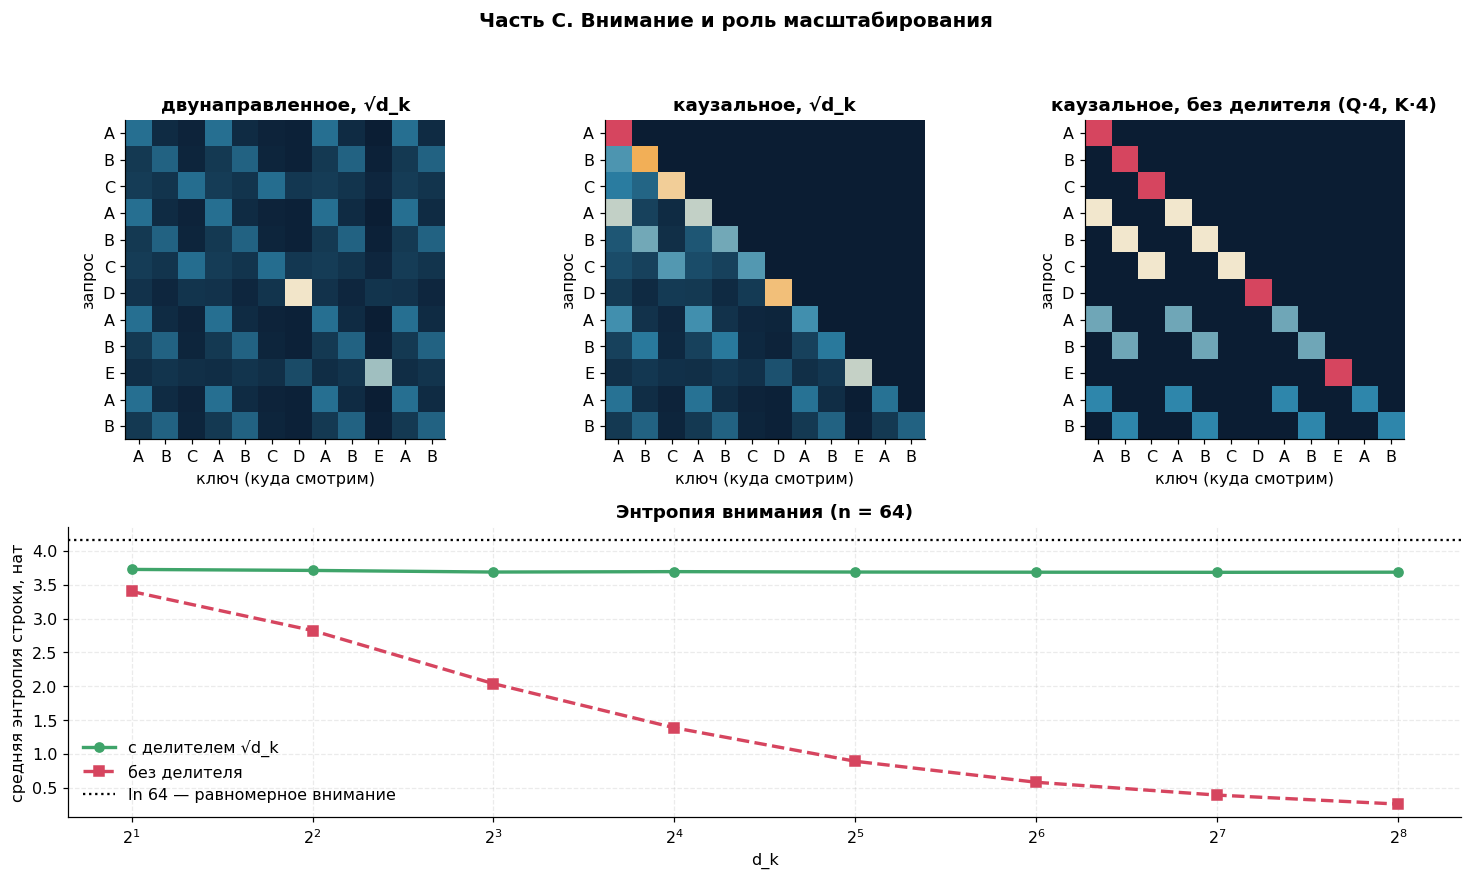

  d_k   с делителем   без делителя
    2         3.725          3.400
    4         3.710          2.824
    8         3.686          2.040
   16         3.692          1.389
   32         3.686          0.896
   64         3.684          0.586
  128         3.682          0.397
  256         3.684          0.264


In [ ]:
n_tok, d_k = 12, 16
labels = ["A", "B", "C", "A", "B", "C", "D", "A", "B", "E", "A", "B"]
g = np.random.default_rng(SEED)
emb = {s: g.normal(size=d_k) for s in sorted(set(labels))}
X = np.stack([emb[s] for s in labels])            # одинаковые токены → одинаковые векторы
_, W_bi = attention(X, X, X, causal=False, scale=True)
_, W_ca = attention(X, X, X, causal=True, scale=True)
_, W_ns = attention(X * 4, X * 4, X, causal=True, scale=False)

DKS = [2, 4, 8, 16, 32, 64, 128, 256]
ent_s = [mean_entropy(d, True) for d in DKS]
ent_n = [mean_entropy(d, False) for d in DKS]

fig = plt.figure(figsize=(13.5, 8))
gs = fig.add_gridspec(2, 3, height_ratios=[1.1, 1])
for j, (Wm, title) in enumerate([(W_bi, "двунаправленное, √d_k"), (W_ca, "каузальное, √d_k"),
                                 (W_ns, "каузальное, без делителя (Q·4, K·4)")]):
    ax = fig.add_subplot(gs[0, j])
    ax.imshow(Wm, cmap=CMAP_HEAT, vmin=0, vmax=1)
    ax.set_xticks(range(n_tok)); ax.set_xticklabels(labels); ax.set_yticks(range(n_tok)); ax.set_yticklabels(labels)
    ax.set_xlabel("ключ (куда смотрим)"); ax.set_ylabel("запрос"); ax.grid(False); ax.set_title(title)
ax = fig.add_subplot(gs[1, :])
ax.semilogx(DKS, ent_s, "o-", color=PALETTE["good"], lw=2.2, label="с делителем √d_k", base=2)
ax.semilogx(DKS, ent_n, "s--", color=PALETTE["bad"], lw=2.2, label="без делителя", base=2)
ax.axhline(np.log(64), ls=":", color="k", label="ln 64 — равномерное внимание")
ax.set_xlabel("d_k"); ax.set_ylabel("средняя энтропия строки, нат"); ax.set_title("Энтропия внимания (n = 64)")
ax.legend()
finish(fig, "Часть C. Внимание и роль масштабирования")

print(f"{'d_k':>5}{'с делителем':>14}{'без делителя':>15}")
for d, a, b in zip(DKS, ent_s, ent_n):
    print(f"{d:>5}{a:>14.3f}{b:>15.3f}")

Каузальная маска запрещает смотреть в будущее: элементы выше главной диагонали заменяются на −∞, после softmax они становятся нулями. Это нужно, чтобы при обучении предсказывать следующий токен, не подглядывая в ответ.

**Вопрос C.** Почему вырождение softmax в one-hot останавливает обучение?

**Ответ C.** Производная softmax по логитам:

$$\frac{\partial p_i}{\partial z_j} = p_i\,(\delta_{ij} - p_j).$$

Если распределение почти one-hot ($p_{i^*} \approx 1$, остальные $\approx 0$), то для $i = i^*$ получаем $p_{i^*}(1 - p_{i^*}) \approx 0$, а для всех остальных $i$ множитель $p_i \approx 0$. Весь якобиан softmax близок к нулю, и градиент, приходящий к логитам $z = qk^\top/\sqrt{d_k}$, а через них — к весам $W_Q$ и $W_K$, исчезает. Модель перестаёт учиться, **куда смотреть**: внимание «застывает» на случайно выбранной позиции. Это та же картина насыщения, что у сигмоиды на краях.

Измерения это подтверждают. Без делителя энтропия внимания падает с 2.04 нат при $d_k = 8$ до 0.586 при $d_k = 64$ и до 0.264 при $d_k = 256$ — распределение всё ближе к one-hot, потому что дисперсия $q^\top k$ равна $d_k$ и логиты растут как $\sqrt{d_k}$. С делителем $\sqrt{d_k}$ дисперсия логитов нормирована к единице, и энтропия остаётся примерно постоянной (3.68–3.69 нат при любом $d_k$, чуть ниже максимума $\ln 64 = 4.16$). То же видно на третьей карте внимания: при увеличении $Q$ и $K$ в 4 раза без делителя каждая строка превращается в почти единственную яркую клетку.

## Часть D. Позиционные кодировки: синусоида, RoPE, ALiBi

Внимание перестановочно инвариантно, поэтому порядок вносится отдельно:

- синусоидальная кодировка добавляется к эмбеддингу (абсолютная позиция);
- **RoPE** поворачивает $q$ и $k$ на угол, пропорциональный позиции, так что
  $\langle R_t q, R_s k\rangle = f(q,k,t-s)$;
- **ALiBi** добавляет к логитам линейный штраф $-m|t-s|$.

**Задание D.1.** Реализуйте синусоидальную кодировку.
**Задание D.2.** Реализуйте RoPE и численно проверьте зависимость только от $t-s$: постройте
$\langle R_{t}q, R_{s}k\rangle$ для нескольких абсолютных начал при одинаковых разностях позиций.
**Задание D.3.** Постройте матрицу штрафов ALiBi для одной головы и рисунок из трёх панелей.

In [ ]:
def sinusoidal(n, d):
    pos = np.arange(n)[:, None]
    i = np.arange(d)[None, :]
    angle = pos / (10000 ** ((i - i % 2) / d))      # у пары (2j, 2j+1) общая частота
    pe = np.zeros((n, d))
    pe[:, 0::2] = np.sin(angle[:, 0::2])
    pe[:, 1::2] = np.cos(angle[:, 1::2])
    return pe

def rope_apply(x, pos, base=10000.0):
    x = np.asarray(x, dtype=float)
    d = x.shape[-1]; half = d // 2
    theta = pos / base ** (2 * np.arange(half) / d)
    c, s = np.cos(theta), np.sin(theta)
    x1, x2 = x[..., :half], x[..., half:]
    return np.concatenate([x1 * c - x2 * s, x1 * s + x2 * c], axis=-1)

g = np.random.default_rng(SEED)
q, k = g.normal(size=32), g.normal(size=32)
deltas = np.arange(0, 40)
starts = [0, 7, 100, 1000]
rope_curves = {s0: np.array([rope_apply(q, s0 + dl) @ rope_apply(k, s0) for dl in deltas]) for s0 in starts}
disc = max(np.abs(rope_curves[s0] - rope_curves[0]).max() for s0 in starts)
print(f"максимальное расхождение ⟨R_t q, R_s k⟩ при одинаковой t−s и разных началах: {disc:.2e}")

максимальное расхождение ⟨R_t q, R_s k⟩ при одинаковой t−s и разных началах: 1.40e-13


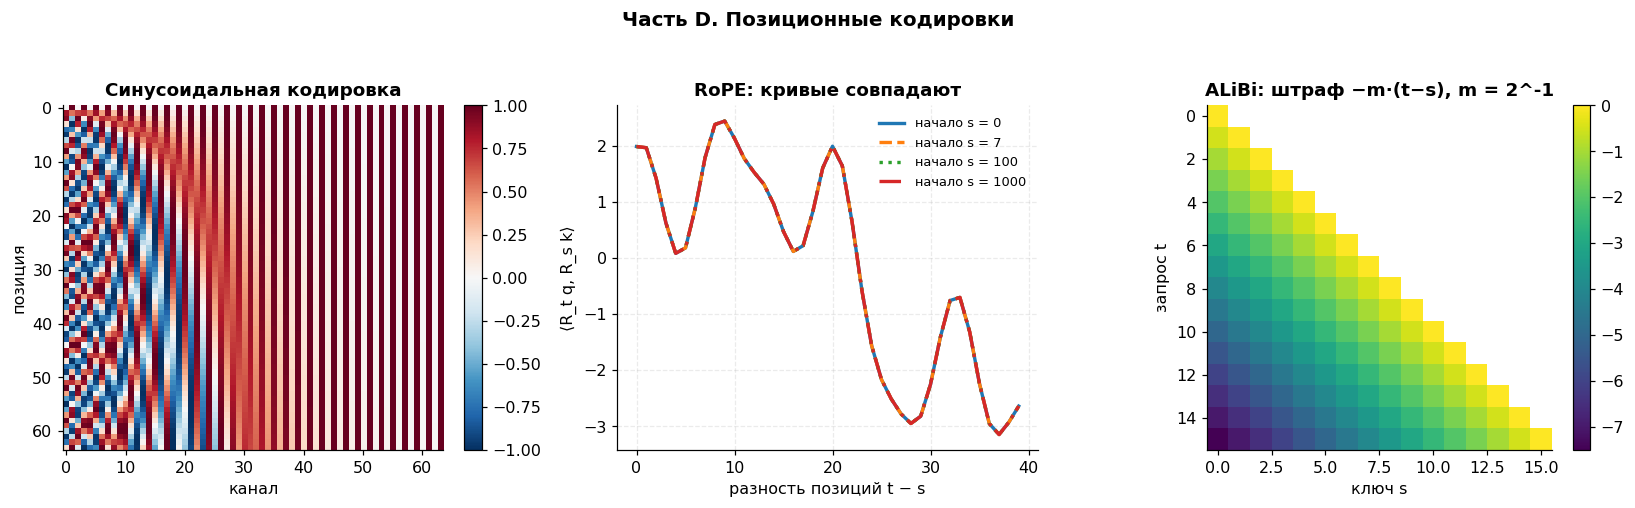

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
pe = sinusoidal(64, 64)
im = axes[0].imshow(pe, cmap="RdBu_r", aspect="auto", vmin=-1, vmax=1)
axes[0].set_xlabel("канал"); axes[0].set_ylabel("позиция"); axes[0].grid(False)
axes[0].set_title("Синусоидальная кодировка"); fig.colorbar(im, ax=axes[0], fraction=0.046)

for s0, ls in zip(starts, ["-", "--", ":", "-."]):
    axes[1].plot(deltas, rope_curves[s0], ls=ls, lw=2.2, label=f"начало s = {s0}")
axes[1].set_xlabel("разность позиций t − s"); axes[1].set_ylabel("⟨R_t q, R_s k⟩")
axes[1].set_title("RoPE: кривые совпадают"); axes[1].legend(fontsize=8.5)

n_al, h_al = 16, 1
m_h = 2.0 ** (-h_al)
t_idx, s_idx = np.meshgrid(np.arange(n_al), np.arange(n_al), indexing="ij")
alibi = -m_h * (t_idx - s_idx).astype(float)
alibi[s_idx > t_idx] = np.nan                     # будущее запрещено маской
im = axes[2].imshow(alibi, cmap="viridis"); axes[2].grid(False)
axes[2].set_xlabel("ключ s"); axes[2].set_ylabel("запрос t")
axes[2].set_title(f"ALiBi: штраф −m·(t−s), m = 2^-{h_al}"); fig.colorbar(im, ax=axes[2], fraction=0.046)
finish(fig, "Часть D. Позиционные кодировки")

**Вопрос D.** Какая схема позволяет работать с позициями, которых не было в обучении, и почему? Что будет с обучаемой абсолютной кодировкой?

**Ответ D.** Лучше всего экстраполируют **относительные** схемы, в первую очередь **ALiBi**, а также RoPE.

- **ALiBi** добавляет к логиту штраф $-m|t-s|$, который зависит только от расстояния и задан формулой, а не обучен. Для расстояний больше обучающих штраф просто продолжает линейно расти, и модель ведёт себя предсказуемо — «чем дальше, тем меньше внимания».
- **RoPE** поворачивает $q$ и $k$ на углы, пропорциональные позиции, и скалярное произведение зависит только от $t-s$. Это проверено численно: при одинаковой разности позиций и абсолютных началах 0, 7, 100 и 1000 кривые совпадают с точностью $1.4\cdot10^{-13}$. Модель не видит абсолютных номеров, только относительные, поэтому сдвиг всего окна не меняет её поведения. Но расстояний, больших обучающих, модель не видела, и на высоких частотах поворота возникают незнакомые углы; поэтому для длинного контекста RoPE дополняют интерполяцией позиций (PI, NTK, YaRN).
- **Синусоидальная** кодировка формально определена для любой позиции, но она абсолютная и добавляется к эмбеддингу: сочетания значений на новых позициях модель не видела.

**Обучаемая абсолютная кодировка** — это таблица из `max_len` строк. За пределами `max_len` строк просто нет (ошибка индекса), а позиции внутри таблицы, но длиннее обучающих примеров, остаются с необученными (случайными, стянутыми weight decay) векторами. Именно это мы наблюдаем в части E: модель обучалась максимум на 12 парах (длина до 25 токенов) и на них даёт точность 0.996–1.000, а на 16 парах (33 токена) — 0.688, на 20 парах (41 токен) — 0.578. Сам механизм вспоминания длины не боится, ломается именно позиционная информация.

## Часть E. Мини-трансформер и индукционная голова

Задача **ассоциативного вспоминания**: последовательность пар «ключ, значение», затем повтор одного
из ключей; модель должна выдать соответствующее значение:

$
k_1\,v_1\,k_2\,v_2\,\dots\,k_N\,v_N\ \ k_i \;\longrightarrow\; v_i .
$

Минимальное решение — схема из двух слоёв (индукционная голова): первый слой переносит в позицию
ключа информацию о следующем токене, второй сравнивает финальный запрос с ключами.

**Задание E.1.** Реализуйте блок трансформера: пред-нормализация, одна голова каузального внимания,
FFN, остаточные связи.
**Задание E.2.** Обучите модель (обучение идёт на 2…`N_MAX` парах) и измерьте точность для
2…20 пар, включая длины больше обучающих.
**Задание E.3.** Постройте карты внимания обоих слоёв для одного примера и найдите индукционную
схему.

In [ ]:
N_KEYS, N_VALS = 256, 16
VOCAB = N_KEYS + N_VALS

def make_recall_batch(bs, n_pairs, gen):
    keys = torch.stack([torch.randperm(N_KEYS, generator=gen)[:n_pairs] for _ in range(bs)])
    vals = torch.randint(N_KEYS, VOCAB, (bs, n_pairs), generator=gen)
    seq = torch.zeros(bs, 2 * n_pairs + 1, dtype=torch.long)
    seq[:, 0:2 * n_pairs:2] = keys
    seq[:, 1:2 * n_pairs:2] = vals
    qi = torch.randint(0, n_pairs, (bs,), generator=gen)
    seq[:, -1] = keys[torch.arange(bs), qi]
    return seq, vals[torch.arange(bs), qi], qi

class Block(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.d = d
        self.q = nn.Linear(d, d, bias=False); self.k = nn.Linear(d, d, bias=False)
        self.v = nn.Linear(d, d, bias=False); self.o = nn.Linear(d, d, bias=False)
        self.ln1 = nn.LayerNorm(d); self.ln2 = nn.LayerNorm(d)
        self.ff = nn.Sequential(nn.Linear(d, 4 * d), nn.GELU(), nn.Linear(4 * d, d))

    def forward(self, h, ret=False):
        x = self.ln1(h); T = h.shape[1]
        q, k, v = self.q(x), self.k(x), self.v(x)
        s = q @ k.transpose(1, 2) / math.sqrt(self.d)
        s = s.masked_fill(torch.triu(torch.ones(T, T, dtype=torch.bool), 1), float("-inf"))
        att = s.softmax(-1)
        a = att @ v
        h = h + self.o(a)                    # остаточная связь вокруг внимания
        h = h + self.ff(self.ln2(h))         # остаточная связь вокруг FFN
        return h, (att.detach() if ret else None)

class TinyTransformer(nn.Module):
    def __init__(self, d=64, max_len=90, n_layers=2):
        super().__init__()
        self.emb = nn.Embedding(VOCAB, d); self.pos = nn.Embedding(max_len, d)
        self.blocks = nn.ModuleList([Block(d) for _ in range(n_layers)])
        self.lnf = nn.LayerNorm(d); self.head = nn.Linear(d, VOCAB)

    def forward(self, x, ret=False):
        h = self.emb(x) + self.pos(torch.arange(x.shape[1]))
        maps = []
        for b in self.blocks:
            h, a = b(h, ret); maps.append(a)
        return self.head(self.lnf(h)[:, -1]), maps

print("размер словаря задачи:", VOCAB, "| случайное угадывание: %.3f" % (1 / N_VALS))

размер словаря задачи: 272 | случайное угадывание: 0.062


In [ ]:
def train_recall(steps=2600, bs=64, lr=2e-3, seed=0, n_max=12):
    gen = torch.Generator().manual_seed(seed)
    torch.manual_seed(seed)
    m = TinyTransformer(d=D_MODEL)
    opt = torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=0.01)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=lr, total_steps=steps, pct_start=0.15)
    curve = []
    for s in range(steps):
        n = int(torch.randint(2, n_max + 1, (1,), generator=gen))   # смешанные длины
        x, y, _ = make_recall_batch(bs, n, gen)
        logits, _ = m(x)
        loss = F.cross_entropy(logits, y)
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
        opt.step(); sched.step()
        curve.append(loss.item())
    return m, curve, gen

@torch.no_grad()
def acc_vs_pairs(m, gen, ns, bs=256):
    m.eval()
    out = []
    for n in ns:
        x, y, _ = make_recall_batch(bs, n, gen)
        out.append(float((m(x)[0].argmax(-1) == y).float().mean()))
    m.train()
    return out

NS = [2, 4, 6, 8, 10, 12, 16, 20]
t0 = time.time()
model, curve, gen_m = train_recall(seed=SEED, n_max=N_MAX)
acc = acc_vs_pairs(model, gen_m, NS)
train_time = time.time() - t0
print("обучение заняло %.0f c" % train_time)
print("финальная потеря (среднее за 100 последних шагов): %.4f" % np.mean(curve[-100:]))
print("точность по числу пар:", dict(zip(NS, [round(a, 3) for a in acc])))

обучение заняло 60 c
финальная потеря (среднее за 100 последних шагов): 0.0081
точность по числу пар: {2: 0.996, 4: 1.0, 6: 1.0, 8: 1.0, 10: 1.0, 12: 0.996, 16: 0.688, 20: 0.578}


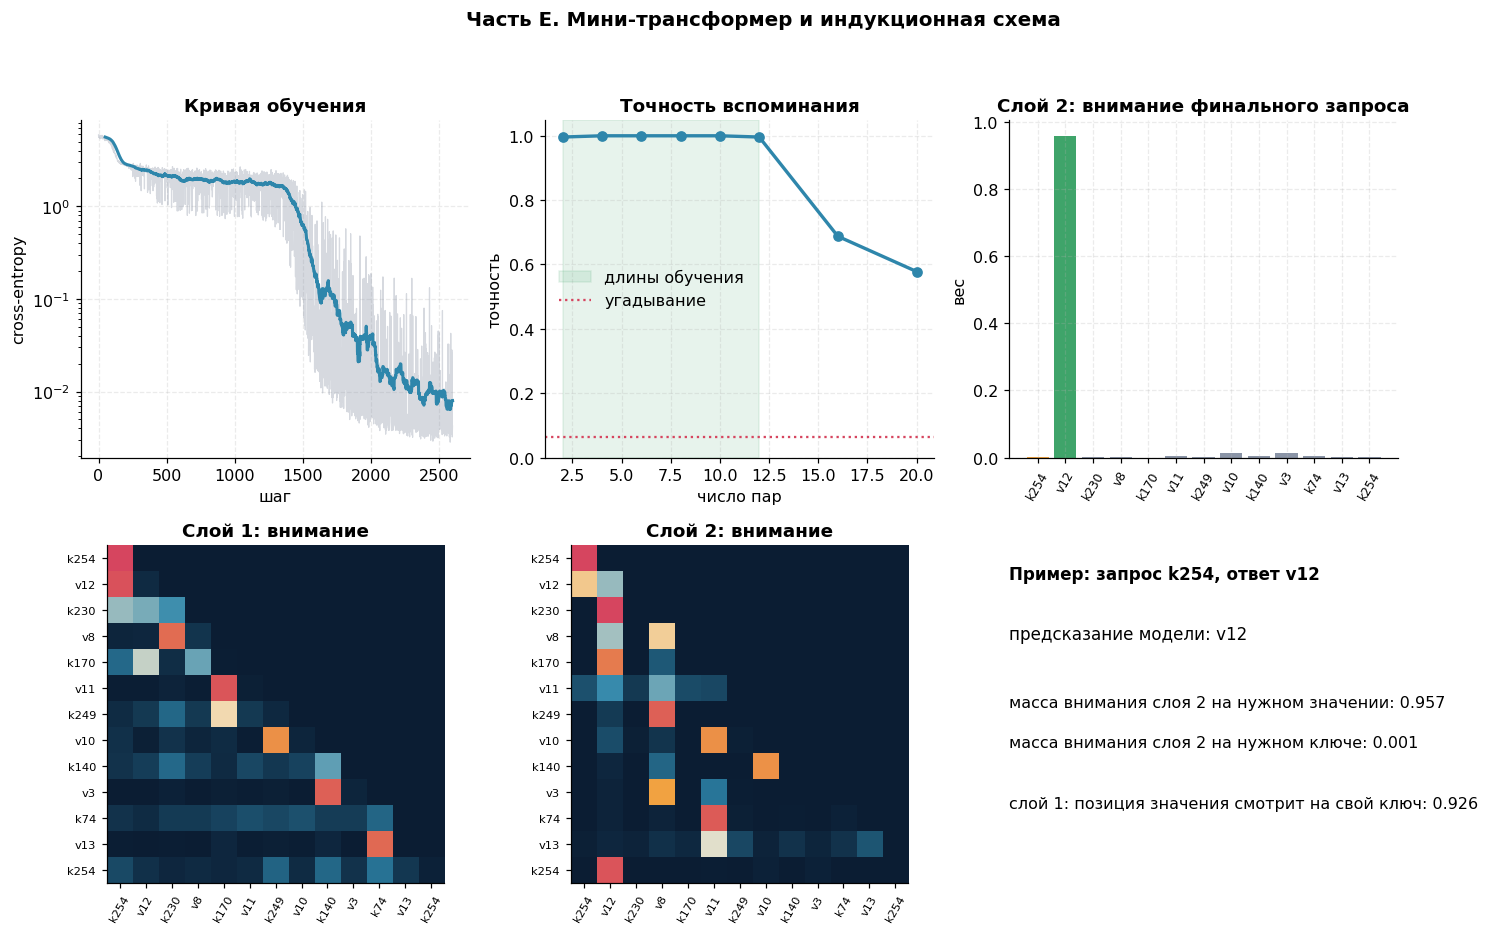

масса внимания финального запроса на позиции нужного значения: 0.957
масса внимания финального запроса на позиции нужного ключа:    0.001
слой 1: средняя доля внимания позиции значения на предыдущий токен: 0.926


In [ ]:
x_ex, y_ex, qi_ex = make_recall_batch(1, 6, torch.Generator().manual_seed(123))
model.eval()
with torch.no_grad():
    logits_ex, maps = model(x_ex, ret=True)
qi = int(qi_ex[0]); key_pos, val_pos = 2 * qi, 2 * qi + 1
tok_lbl = [f"k{int(t)}" if t < N_KEYS else f"v{int(t) - N_KEYS}" for t in x_ex[0]]

# средняя масса внимания финального запроса (слой 2) по 512 примерам с 6 парами
with torch.no_grad():
    xb, yb, qb = make_recall_batch(512, 6, torch.Generator().manual_seed(7))
    _, mb = model(xb, ret=True)
last = mb[1][:, -1, :]
mass_val = float(last[torch.arange(512), 2 * qb + 1].mean())
mass_key = float(last[torch.arange(512), 2 * qb].mean())
# «индукционный» признак слоя 1: доля внимания позиций значений на предыдущий токен (ключ)
l1 = mb[0]
prev_mass = float(torch.stack([l1[:, p, p - 1] for p in range(1, 12, 2)], 1).mean())
model.train()

fig = plt.figure(figsize=(14, 8.5))
gs = fig.add_gridspec(2, 3)
ax = fig.add_subplot(gs[0, 0])
sm = np.convolve(curve, np.ones(50) / 50, mode="valid")
ax.plot(curve, color=PALETTE["gray"], alpha=0.35, lw=0.8); ax.plot(np.arange(49, len(curve)), sm, color=PALETTE["attn"], lw=2)
ax.set_yscale("log"); ax.set_xlabel("шаг"); ax.set_ylabel("cross-entropy"); ax.set_title("Кривая обучения")
ax = fig.add_subplot(gs[0, 1])
ax.axvspan(2, N_MAX, color=PALETTE["good"], alpha=0.12, label="длины обучения")
ax.plot(NS, acc, "o-", color=PALETTE["attn"], lw=2.2)
ax.axhline(1 / N_VALS, ls=":", color=PALETTE["bad"], label="угадывание")
ax.set_ylim(0, 1.05); ax.set_xlabel("число пар"); ax.set_ylabel("точность"); ax.set_title("Точность вспоминания"); ax.legend()
ax = fig.add_subplot(gs[0, 2])
ax.bar(range(len(tok_lbl)), maps[1][0, -1].numpy(),
       color=[PALETTE["good"] if p == val_pos else PALETTE["linear"] if p == key_pos else PALETTE["gray"] for p in range(len(tok_lbl))])
ax.set_xticks(range(len(tok_lbl))); ax.set_xticklabels(tok_lbl, rotation=60, fontsize=8)
ax.set_title("Слой 2: внимание финального запроса"); ax.set_ylabel("вес")
for j, (att, ttl) in enumerate([(maps[0][0], "Слой 1: внимание"), (maps[1][0], "Слой 2: внимание")]):
    ax = fig.add_subplot(gs[1, j])
    ax.imshow(att.numpy(), cmap=CMAP_HEAT, vmin=0, vmax=1); ax.grid(False)
    ax.set_xticks(range(len(tok_lbl))); ax.set_xticklabels(tok_lbl, rotation=60, fontsize=7.5)
    ax.set_yticks(range(len(tok_lbl))); ax.set_yticklabels(tok_lbl, fontsize=7.5); ax.set_title(ttl)
ax = fig.add_subplot(gs[1, 2]); ax.axis("off")
ax.text(0, 0.9, f"Пример: запрос k{int(x_ex[0, -1])}, ответ v{int(y_ex[0]) - N_KEYS}", fontsize=11, fontweight="bold")
ax.text(0, 0.72, f"предсказание модели: v{int(logits_ex.argmax()) - N_KEYS}", fontsize=11)
ax.text(0, 0.52, f"масса внимания слоя 2 на нужном значении: {mass_val:.3f}", fontsize=10.5)
ax.text(0, 0.40, f"масса внимания слоя 2 на нужном ключе: {mass_key:.3f}", fontsize=10.5)
ax.text(0, 0.22, f"слой 1: позиция значения смотрит на свой ключ: {prev_mass:.3f}", fontsize=10.5)
finish(fig, "Часть E. Мини-трансформер и индукционная схема")
print(f"масса внимания финального запроса на позиции нужного значения: {mass_val:.3f}")
print(f"масса внимания финального запроса на позиции нужного ключа:    {mass_key:.3f}")
print(f"слой 1: средняя доля внимания позиции значения на предыдущий токен: {prev_mass:.3f}")

На длинах обучения (2–12 пар) точность почти идеальная; потеря в конце обучения 0,008, обучение заняло 60 секунд. На 16 и 20 парах точность падает: позиции длиннее 25 токенов модель не видела, и их векторы обучаемой кодировки остались необученными.

**Вопрос E.** Почему недостаточно одного слоя внимания?

**Ответ E.** Финальный токен — это копия ключа $k_i$. Чтобы ответить, модель должна найти **позицию сразу после** этого ключа и скопировать оттуда значение $v_i$. Один слой внимания так не умеет: запрос $k_i$ по сходству находит позицию, где стоит сам $k_i$, но там нет значения, а позиция $v_i$ ничем не похожа на запрос — это просто случайный токен-значение. Для связи «этот ключ» → «следующий за ним токен» нужна информация о соседе, которую содержимое токена само по себе не несёт.

Двухслойная **индукционная схема** решает задачу в два шага, и это прямо видно на картах внимания:

1. **Слой 1** (предыдущий токен): каждая позиция значения $v_j$ смотрит на предыдущую позицию и копирует к себе информацию о своём ключе $k_j$. Измерено: позиции значений отдают предыдущему токену в среднем **92.6 %** внимания — на карте слоя 1 это яркая поддиагональ на строках $v$.
2. **Слой 2** (сравнение и копирование): финальный запрос $k_i$ сравнивается уже не с исходными токенами, а с обогащёнными представлениями, и находит ту позицию $v_i$, которая «помнит», что перед ней стоял $k_i$. Её содержимое и копируется в ответ. Измерено: масса внимания финального запроса на нужном значении — **0.957**, на самом ключе — 0.001.

Кривая обучения подтверждает, что схема возникает скачком: около 1400 шагов потеря держится на плато около 2 (модель знает только распределение значений), затем резко падает до 0.008 — это момент формирования индукционной головы, известный фазовый переход в обучении трансформеров.

## Часть F. Линейное внимание: состояние вместо матрицы внимания

Если заменить $\exp(q^\top k)$ на $\varphi(q)^\top \varphi(k)$ с неотрицательным $\varphi$, сумму
можно переставить и получить рекуррентную форму с состоянием фиксированного размера:

$
S_t = S_{t-1} + \varphi(k_t) v_t^{\top}, \qquad
o_t = \frac{\varphi(q_t)^{\top} S_t}{\varphi(q_t)^{\top} z_t}, \qquad z_t = z_{t-1} + \varphi(k_t).
$

Генерация становится $O(1)$ по памяти, но состояние размера $d \times d$ — это фиксированная
ёмкость, в которую нужно уложить весь контекст.

**Задание F.1.** Реализуйте параллельную и рекуррентную формы линейного внимания и проверьте, что
они дают один результат.
**Задание F.2.** Измерьте ёмкость состояния: сложите в $S$ ровно $N$ пар «ключ–значение» и оцените
качество чтения (косинусная близость к истинному значению) при росте $N$.
**Задание F.3.** Постройте рисунок: рост KV-кэша softmax-внимания против постоянного состояния
линейного внимания и кривую качества чтения от числа сохранённых пар.

In [ ]:
def phi(x):
    return torch.nn.functional.elu(x) + 1          # неотрицательное отображение признаков

def linear_attention_parallel(Q, K, V):
    pq, pk = phi(Q), phi(K)
    S = torch.cumsum(pk[:, :, None] * V[:, None, :], dim=0)   # S_t = Σ_{s≤t} φ(k_s) v_sᵀ, (T, d, d_v)
    z = torch.cumsum(pk, dim=0)                                # z_t = Σ_{s≤t} φ(k_s)
    num = torch.einsum("td,tde->te", pq, S)
    den = (pq * z).sum(-1, keepdim=True)
    return num / den

def linear_attention_recurrent(Q, K, V):
    d, dv = Q.shape[1], V.shape[1]
    S = torch.zeros(d, dv); z = torch.zeros(d)
    outs = []
    for t in range(Q.shape[0]):
        pk, pq = phi(K[t]), phi(Q[t])
        S = S + torch.outer(pk, V[t])
        z = z + pk
        outs.append((pq @ S) / (pq @ z))
    return torch.stack(outs)

torch.manual_seed(SEED)
T_l, d_l = 40, 16
Ql, Kl, Vl = torch.randn(T_l, d_l), torch.randn(T_l, d_l), torch.randn(T_l, d_l)
o_par, o_rec = linear_attention_parallel(Ql, Kl, Vl), linear_attention_recurrent(Ql, Kl, Vl)
lin_disc = float((o_par - o_rec).abs().max())
print(f"максимальное расхождение параллельной и рекуррентной форм: {lin_disc:.2e}")
print(f"размер состояния: S {d_l}×{d_l} + z {d_l} = {d_l * d_l + d_l} чисел (не зависит от T = {T_l})")

максимальное расхождение параллельной и рекуррентной форм: 2.38e-07
размер состояния: S 16×16 + z 16 = 272 чисел (не зависит от T = 40)


In [ ]:
NS_CAP = [1, 2, 4, 8, 16, 32, 64, 128, 256]
g_cap = torch.Generator().manual_seed(SEED)
cap_quality = []
for N in NS_CAP:
    vals = []
    for _ in range(20):
        Kc = torch.randn(N, d_l, generator=g_cap); Vc = torch.randn(N, d_l, generator=g_cap)
        pk = phi(Kc)
        S = pk.T @ Vc; z = pk.sum(0)
        read = (pk @ S) / (pk @ z)[:, None]
        vals.append(float(F.cosine_similarity(read, Vc, dim=1).mean()))
    cap_quality.append(float(np.mean(vals)))
for N, qv in zip(NS_CAP, cap_quality):
    print(f"N = {N:>3}: косинусная близость прочитанного значения к истинному = {qv:.3f}")

N =   1: косинусная близость прочитанного значения к истинному = 1.000
N =   2: косинусная близость прочитанного значения к истинному = 0.829
N =   4: косинусная близость прочитанного значения к истинному = 0.604
N =   8: косинусная близость прочитанного значения к истинному = 0.452
N =  16: косинусная близость прочитанного значения к истинному = 0.336
N =  32: косинусная близость прочитанного значения к истинному = 0.235
N =  64: косинусная близость прочитанного значения к истинному = 0.167
N = 128: косинусная близость прочитанного значения к истинному = 0.117
N = 256: косинусная близость прочитанного значения к истинному = 0.085


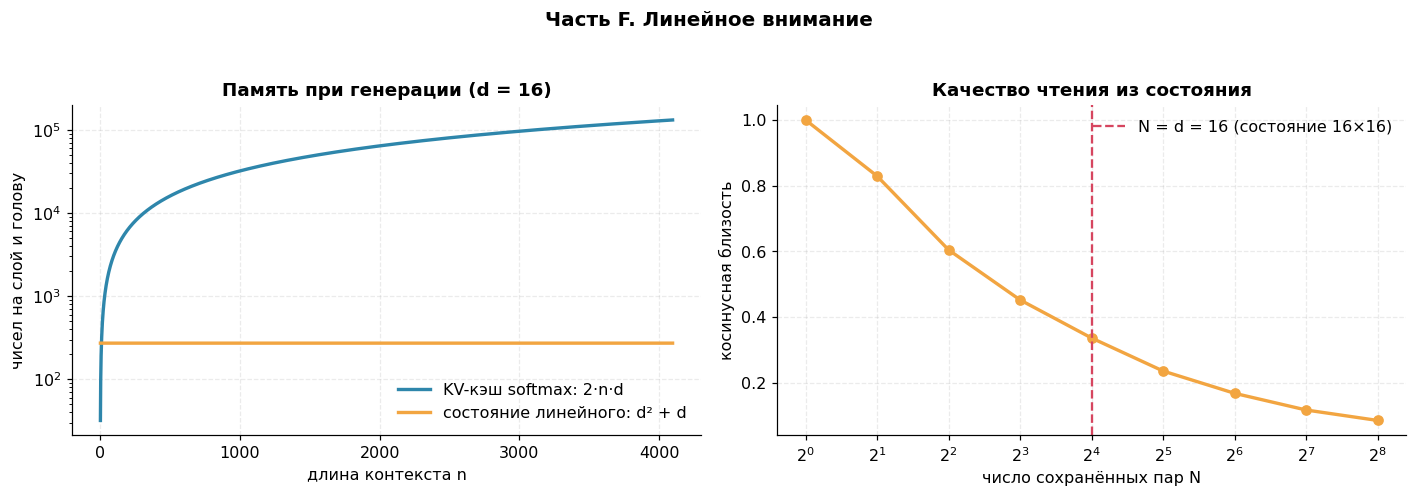

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ctx = np.arange(1, 4097)
axes[0].plot(ctx, 2 * ctx * d_l, color=PALETTE["attn"], lw=2.2, label="KV-кэш softmax: 2·n·d")
axes[0].plot(ctx, np.full_like(ctx, d_l * d_l + d_l), color=PALETTE["linear"], lw=2.2, label="состояние линейного: d² + d")
axes[0].set_xlabel("длина контекста n"); axes[0].set_ylabel("чисел на слой и голову"); axes[0].set_yscale("log")
axes[0].set_title(f"Память при генерации (d = {d_l})"); axes[0].legend()

axes[1].semilogx(NS_CAP, cap_quality, "o-", color=PALETTE["linear"], lw=2.2, base=2)
axes[1].axvline(d_l, ls="--", color=PALETTE["bad"], label=f"N = d = {d_l} (состояние {d_l}×{d_l})")
axes[1].set_xlabel("число сохранённых пар N"); axes[1].set_ylabel("косинусная близость")
axes[1].set_title("Качество чтения из состояния"); axes[1].legend()
finish(fig, "Часть F. Линейное внимание")

**Вопрос F.** Почему увеличение $d$ у линейного внимания повышает точность, но обесценивает главное преимущество? При каком $d$ состояние сравнится с KV-кэшем на 4096 токенах?

**Ответ F.** Состояние $S = \sum_i \varphi(k_i) v_i^\top$ — это сумма внешних произведений в матрице $d \times d$. Прочитать значение без помех можно, пока ключи почти ортогональны, а в пространстве размерности $d$ почти ортогональных векторов порядка $d$. Каждая новая пара добавляет помеху ко всем остальным. Измерено при $d = 16$: при одной паре близость 1.000, при 4 — 0.604, при 16 — 0.336, при 256 — всего 0.085. У признаков $\varphi = \mathrm{elu}+1$ все координаты положительны, ключи никогда не ортогональны, и помехи начинаются сразу со второй пары. Увеличение $d$ раздвигает эту границу — ёмкость растёт примерно пропорционально $d$.

Но размер состояния растёт как $d^2$, а главное преимущество линейного внимания — именно маленькое постоянное состояние вместо растущего KV-кэша. KV-кэш softmax-внимания хранит ключи и значения всех токенов: $2nd$ чисел на слой и голову. Состояние: $d^2$ (+ $d$ для нормировки). Они равны при $d^2 = 2nd$, то есть при $d = 2n$. Для контекста 4096 токенов это **$d = 8192$**, и состояние займёт $8192^2 \approx 6.7\cdot10^{7}$ чисел — ровно столько же, сколько KV-кэш. При этом у softmax-внимания точное вспоминание сохраняется при любой длине, а у линейного ёмкость всё равно ограничена. Поэтому линейное внимание выгодно только при $d \ll n$, но именно тогда оно хуже вспоминает.

Параллельная и рекуррентная формы совпали с точностью $2.4\cdot10^{-7}$ (ошибка округления float32), размер состояния — 272 числа ($16 \times 16 + 16$) независимо от длины последовательности.

## Часть G. Избирательная рекуррентность

Если сделать затухание и запись зависящими от входа

$
h_t = a(x_t) \odot h_{t-1} + b(x_t) \odot u(x_t),
$

то модель получает управляемую память: она может удерживать нужное и игнорировать шум. Это ядро
идеи моделей пространства состояний с избирательностью (Mamba).

Задача: в последовательности длины 64 встречается маркер `FLAG`; нужно назвать символ,
стоящий сразу после него. Всё остальное — шум.

**Задание G.1.** Реализуйте два варианта ячейки: с гейтами, зависящими от входа, и с обучаемым, но
постоянным затуханием.
**Задание G.2.** Обучите оба варианта и сравните точность.
**Задание G.3.** Постройте профили гейтов по позициям и оцените долю каналов, у которых гейт
сохранения превышает 0.9.

In [ ]:
VOC_S, FLAG, T_S = 20, 19, 64

def flag_batch(bs, gen):
    x = torch.randint(0, 16, (bs, T_S), generator=gen)
    pos = torch.randint(2, T_S - 2, (bs,), generator=gen)
    tgt = torch.randint(0, 16, (bs,), generator=gen)
    x[torch.arange(bs), pos] = FLAG
    x[torch.arange(bs), pos + 1] = tgt
    return x, tgt, pos

class RecurCell(nn.Module):
    def __init__(self, d=48, selective=True):
        super().__init__()
        self.selective = selective
        self.emb = nn.Embedding(VOC_S, d)
        self.inp = nn.Linear(2 * d, d)                 # локальное окно ширины 2 (аналог conv1d)
        if selective:
            self.ga = nn.Linear(2 * d, d); self.gb = nn.Linear(2 * d, d)
        else:
            self.logit_a = nn.Parameter(torch.zeros(d))
        self.head = nn.Sequential(nn.LayerNorm(d), nn.Linear(d, VOC_S))

    def forward(self, x, return_gates=False):
        e = self.emb(x); B, Tn, d = e.shape
        e_prev = torch.cat([torch.zeros(B, 1, d), e[:, :-1]], 1)
        ctx = torch.cat([e, e_prev], -1)
        u = self.inp(ctx)
        if self.selective:
            a = torch.sigmoid(self.ga(ctx))            # сохранение: зависит от входа
            b = torch.sigmoid(self.gb(ctx))            # запись: зависит от входа
        else:
            a = torch.sigmoid(self.logit_a).expand(B, Tn, d)   # одно затухание для всех позиций
            b = torch.ones(B, Tn, d)
        h = torch.zeros(B, d)
        for t in range(Tn):
            h = a[:, t] * h + b[:, t] * u[:, t]
        out = self.head(h)
        return (out, (a, b)) if return_gates else out

In [ ]:
def train_cell(selective, steps=600, bs=64, lr=5e-3, seed=0):
    gen = torch.Generator().manual_seed(seed)
    torch.manual_seed(seed)
    m = RecurCell(d=D_CELL, selective=selective)
    opt = torch.optim.AdamW(m.parameters(), lr=lr)
    curve = []
    for s in range(steps):
        x, y, _ = flag_batch(bs, gen)
        loss = F.cross_entropy(m(x), y)
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
        opt.step()
        if s % 25 == 0 or s == steps - 1:
            with torch.no_grad():
                xe, ye, _ = flag_batch(256, gen)
                curve.append((s, float((m(xe).argmax(-1) == ye).float().mean())))
    return m, curve, gen

t0 = time.time()
cell_sel, curve_sel, gen_sel = train_cell(True, seed=SEED)
cell_fix, curve_fix, gen_fix = train_cell(False, seed=SEED)
print("избирательная ячейка: точность %.3f" % curve_sel[-1][1])
print("фиксированное затухание: точность %.3f (угадывание %.3f)" % (curve_fix[-1][1], 1 / 16))
print("обучение заняло %.0f c" % (time.time() - t0))
print("выученное постоянное затухание: a от %.3f до %.3f (медиана %.3f)" % tuple(
    torch.sigmoid(cell_fix.logit_a).detach().quantile(torch.tensor([0.0, 1.0, 0.5])).tolist()))

избирательная ячейка: точность 1.000
фиксированное затухание: точность 0.070 (угадывание 0.062)
обучение заняло 56 c
выученное постоянное затухание: a от 0.473 до 0.657 (медиана 0.520)


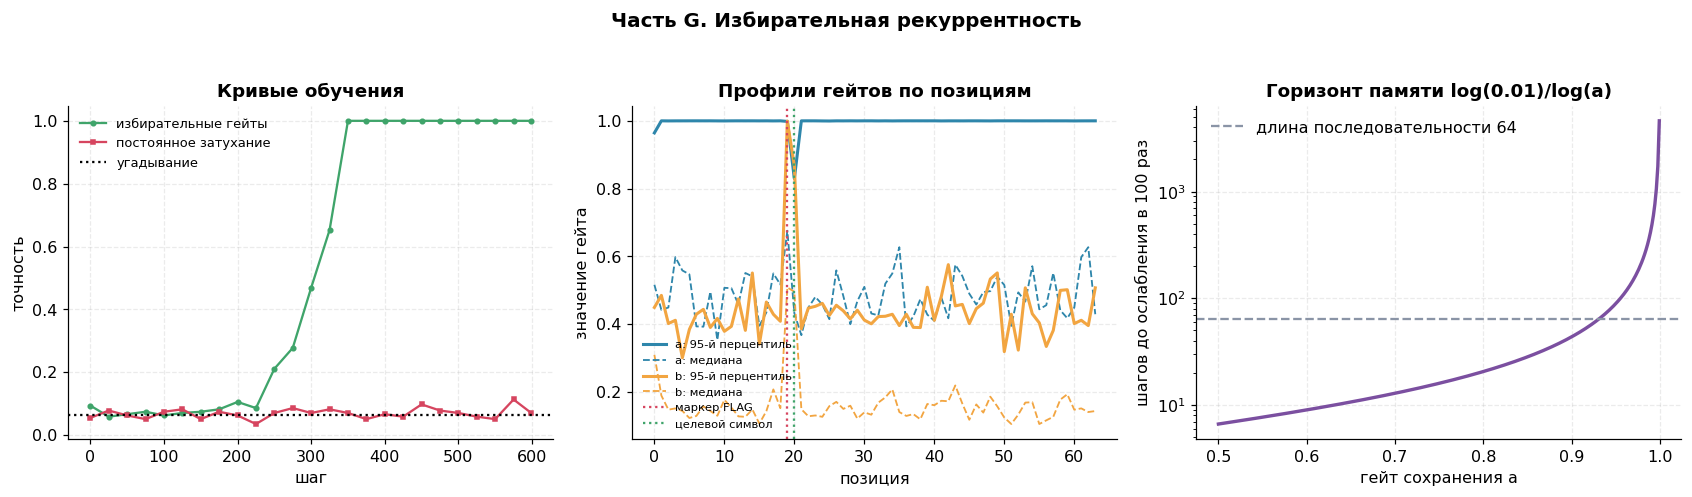

доля каналов с гейтом сохранения a > 0.9 (все позиции): 0.191
то же после записи целевого символа: 0.196
средний гейт записи b: на позиции цели 0.498, в среднем по всем позициям 0.188


In [ ]:
xs, ys, pos = flag_batch(1, torch.Generator().manual_seed(77))
with torch.no_grad():
    _, (a_g, b_g) = cell_sel(xs, return_gates=True)
    xb, yb, pb = flag_batch(256, torch.Generator().manual_seed(5))
    _, (a_b, b_b) = cell_sel(xb, return_gates=True)
p0 = int(pos[0])
a95 = np.percentile(a_g[0].numpy(), 95, axis=1); b95 = np.percentile(b_g[0].numpy(), 95, axis=1)
a_med = np.median(a_g[0].numpy(), axis=1); b_med = np.median(b_g[0].numpy(), axis=1)
share_keep = float((a_b > 0.9).float().mean())
# после цели: какая доля каналов «держит» (a > 0.9) на позициях после записи символа
after = torch.stack([ (a_b[i, int(pb[i]) + 2:] > 0.9).float().mean() for i in range(256) if int(pb[i]) + 2 < T_S ])
share_keep_after = float(after.mean())
# запись: насколько b на позиции цели выше, чем на остальных
b_tgt = float(torch.stack([b_b[i, int(pb[i]) + 1].mean() for i in range(256)]).mean())
b_all = float(b_b.mean())

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.5))
axes[0].plot(*zip(*curve_sel), "o-", ms=3, color=PALETTE["good"], label="избирательные гейты")
axes[0].plot(*zip(*curve_fix), "s-", ms=3, color=PALETTE["bad"], label="постоянное затухание")
axes[0].axhline(1 / 16, ls=":", color="k", label="угадывание")
axes[0].set_xlabel("шаг"); axes[0].set_ylabel("точность"); axes[0].set_title("Кривые обучения"); axes[0].legend(fontsize=8.5)

t_ax = np.arange(T_S)
axes[1].plot(t_ax, a95, color=PALETTE["attn"], lw=2, label="a: 95-й перцентиль")
axes[1].plot(t_ax, a_med, color=PALETTE["attn"], lw=1.2, ls="--", label="a: медиана")
axes[1].plot(t_ax, b95, color=PALETTE["linear"], lw=2, label="b: 95-й перцентиль")
axes[1].plot(t_ax, b_med, color=PALETTE["linear"], lw=1.2, ls="--", label="b: медиана")
axes[1].axvline(p0, color=PALETTE["bad"], ls=":", label="маркер FLAG"); axes[1].axvline(p0 + 1, color=PALETTE["good"], ls=":", label="целевой символ")
axes[1].set_xlabel("позиция"); axes[1].set_ylabel("значение гейта"); axes[1].set_title("Профили гейтов по позициям")
axes[1].legend(fontsize=7.5, loc="lower left")

aa = np.linspace(0.5, 0.999, 300)
axes[2].semilogy(aa, np.log(0.01) / np.log(aa), color=PALETTE["accent"], lw=2.2)
axes[2].axhline(T_S, ls="--", color=PALETTE["gray"], label=f"длина последовательности {T_S}")
axes[2].set_xlabel("гейт сохранения a"); axes[2].set_ylabel("шагов до ослабления в 100 раз")
axes[2].set_title("Горизонт памяти log(0.01)/log(a)"); axes[2].legend()
finish(fig, "Часть G. Избирательная рекуррентность")
print(f"доля каналов с гейтом сохранения a > 0.9 (все позиции): {share_keep:.3f}")
print(f"то же после записи целевого символа: {share_keep_after:.3f}")
print(f"средний гейт записи b: на позиции цели {b_tgt:.3f}, в среднем по всем позициям {b_all:.3f}")

**Вопрос G.** Почему постоянное затухание не решает задачу ни при каком $a$?

**Ответ G.** Результат: избирательная ячейка — точность **1.000**, ячейка с постоянным затуханием — **0.070**, то есть уровень угадывания (0.062). Задача требует двух несовместимых режимов памяти в разных местах одной последовательности: **до** маркера всё нужно забывать, **после** записи целевого символа — хранить без потерь до конца. С постоянным $a$ одно исключает другое.

- **$a \to 1$** (долгая память): состояние накапливает **все** 64 символа почти с одинаковым весом. Целевой символ записан, но утоплен в сумме 63 шумовых символов — сигнал не отличить от помехи.
- **$a \ll 1$** (короткая память): шум быстро забывается, но так же быстро исчезает и целевой символ. Он стоит в случайной позиции от 3 до 63, и если до конца последовательности остаётся больше нескольких шагов, от него ничего не остаётся. Горизонт до ослабления в 100 раз равен $\ln 0.01 / \ln a$; обучение выбрало $a \approx 0.47$–$0.66$ (медиана 0.52), что даёт горизонт около 7 шагов — модель «помнит» только цель у самого конца.

Любое промежуточное $a$ лишь смешивает оба недостатка. Нужно не число, а **правило**, зависящее от входа: «увидел FLAG — запиши следующий символ и держи». Избирательная ячейка это выучила: гейт записи $b$ на позиции цели в среднем **0.498** против 0.188 по всем позициям (в 2.6 раза выше), а **19.1 %** каналов имеют гейт сохранения $a > 0.9$ — это «хранилище», которое почти не затухает и удерживает записанный символ до конца. Именно так работают избирательные модели пространства состояний (Mamba).

## Часть H. Декодирование, статистика попыток и мост к следующей теме

Модель задаёт распределение, а текст получается процедурой выборки. Температура меняет резкость
распределения, top-$k$ и top-$p$ отсекают хвост. Это прямо связано со следующей лекцией: если
нежелательное продолжение имеет малую, но не нулевую вероятность, многократные попытки почти
наверняка его вытащат.

**Задание H.1.** Реализуйте softmax с температурой, top-$k$ и top-$p$ отсечение.
**Задание H.2.** Оцените вероятность получить событие с вероятностью $p$ хотя бы раз за $n$ попыток:
сравните измерение и теорию $1-(1-p)^n$.
**Задание H.3.** Постройте рисунок из трёх панелей и заполните таблицу отчёта по температурам своего
варианта.
**Задание H.4.** Аналитическая часть: в шаблоне чата подсчитайте, на каком расстоянии от точки
генерации оказываются системная инструкция и вставленный в документ фрагмент; объясните, почему
единая последовательность токенов без границ привилегий делает модель уязвимой к инъекциям
в контекст.

In [ ]:
V_dec = 40
rank = np.arange(1, V_dec + 1)
logits = np.log(1.0 / rank ** 1.1)
logits = logits - logits.max()

def softmax_t(z, tau):
    z = np.asarray(z, dtype=float) / tau
    z = z - z.max()
    e = np.exp(z)
    return e / e.sum()

def top_k_filter(p, k):
    keep = np.argsort(p)[::-1][:k]
    q = np.zeros_like(p); q[keep] = p[keep]
    return q / q.sum()

def top_p_filter(p, thr):
    order = np.argsort(p)[::-1]
    cum = np.cumsum(p[order])
    n_keep = int(np.searchsorted(cum, thr) + 1)      # минимальный набор с суммой ≥ thr
    q = np.zeros_like(p); q[order[:n_keep]] = p[order[:n_keep]]
    return q / q.sum()

def entropy(p):
    return float(-(p * np.log(p + 1e-12)).sum())

In [ ]:
g_h = np.random.default_rng(SEED)
P_RARE = [0.001, 0.005, 0.02]
N_TRY = np.arange(20, 361, 20)
REP = 60
measured = {p: [float((g_h.random((REP, n)) < p).any(axis=1).mean()) for n in N_TRY] for p in P_RARE}
theory = {p: 1 - (1 - p) ** N_TRY for p in P_RARE}
for p in P_RARE:
    err = np.abs(np.array(measured[p]) - theory[p]).max()
    print(f"p = {p}: при n = 360 измерено {measured[p][-1]:.3f}, теория {theory[p][-1]:.3f}; макс. отклонение {err:.3f}")
n_09 = int(np.ceil(np.log(0.1) / np.log(1 - 0.005)))
print(f"попыток для p = 0.005 до вероятности 0.9: {n_09}")

p = 0.001: при n = 360 измерено 0.333, теория 0.302; макс. отклонение 0.095
p = 0.005: при n = 360 измерено 0.817, теория 0.835; макс. отклонение 0.095
p = 0.02: при n = 360 измерено 1.000, теория 0.999; макс. отклонение 0.071
попыток для p = 0.005 до вероятности 0.9: 460


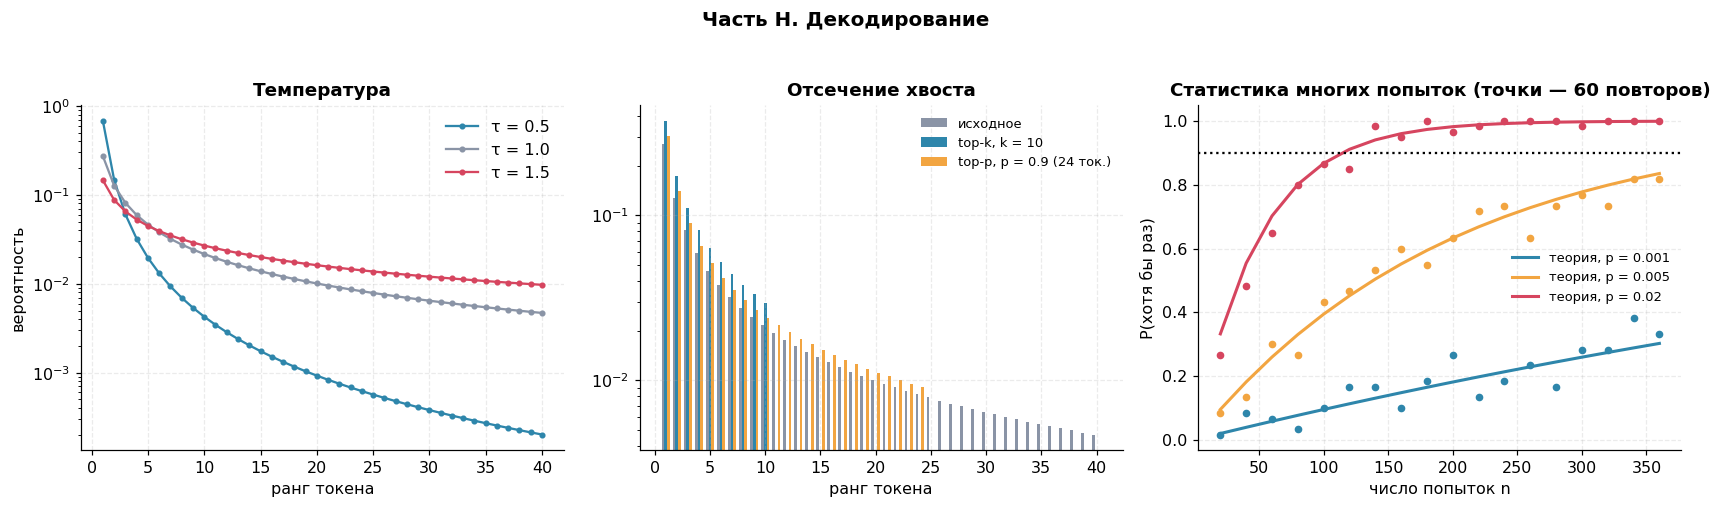

    τ   энтропия, нат    p_max    P(хвост ≥ 20-го ранга)
  0.5           1.269    0.675                     0.009
  1.0           2.888    0.272                     0.142
  1.5           3.368    0.146                     0.259
top-k (k=10): энтропия 1.928; top-p (0.9): 24 токенов, энтропия 2.549


In [ ]:
p_base = softmax_t(logits, 1.0)
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6))
for tau, c in zip(TAUS, [PALETTE["attn"], PALETTE["gray"], PALETTE["bad"]]):
    axes[0].semilogy(rank, softmax_t(logits, tau), "o-", ms=3, color=c, label=f"τ = {tau}")
axes[0].set_xlabel("ранг токена"); axes[0].set_ylabel("вероятность"); axes[0].set_title("Температура"); axes[0].legend()

pk_ = top_k_filter(p_base, 10); pp_ = top_p_filter(p_base, 0.9)
axes[1].bar(rank - 0.25, p_base, 0.25, color=PALETTE["gray"], label="исходное")
axes[1].bar(rank, pk_, 0.25, color=PALETTE["attn"], label="top-k, k = 10")
axes[1].bar(rank + 0.25, pp_, 0.25, color=PALETTE["linear"], label=f"top-p, p = 0.9 ({int((pp_ > 0).sum())} ток.)")
axes[1].set_yscale("log"); axes[1].set_xlabel("ранг токена"); axes[1].set_title("Отсечение хвоста"); axes[1].legend(fontsize=8.5)

for p, c in zip(P_RARE, [PALETTE["attn"], PALETTE["linear"], PALETTE["bad"]]):
    axes[2].plot(N_TRY, theory[p], color=c, lw=2, label=f"теория, p = {p}")
    axes[2].plot(N_TRY, measured[p], "o", color=c, ms=4)
axes[2].axhline(0.9, ls=":", color="k")
axes[2].set_xlabel("число попыток n"); axes[2].set_ylabel("P(хотя бы раз)"); axes[2].set_title("Статистика многих попыток (точки — 60 повторов)")
axes[2].legend(fontsize=8.5)
finish(fig, "Часть H. Декодирование")

print(f"{'τ':>5}{'энтропия, нат':>16}{'p_max':>9}{'P(хвост ≥ 20-го ранга)':>26}")
for tau in TAUS:
    pt = softmax_t(logits, tau)
    print(f"{tau:>5}{entropy(pt):>16.3f}{pt.max():>9.3f}{pt[19:].sum():>26.3f}")
print(f"top-k (k=10): энтропия {entropy(pk_):.3f}; top-p (0.9): {int((pp_ > 0).sum())} токенов, энтропия {entropy(pp_):.3f}")

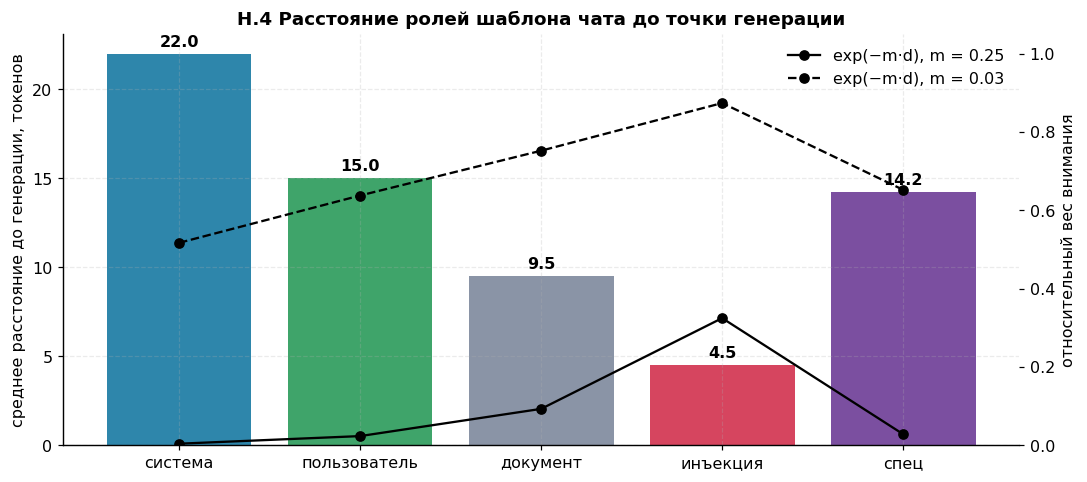

длина последовательности: 26
система        среднее расстояние  22.0 | вес при m=0.25: 0.004 | при m=0.03: 0.517
пользователь   среднее расстояние  15.0 | вес при m=0.25: 0.024 | при m=0.03: 0.638
документ       среднее расстояние   9.5 | вес при m=0.25: 0.093 | при m=0.03: 0.752
инъекция       среднее расстояние   4.5 | вес при m=0.25: 0.325 | при m=0.03: 0.874
спец           среднее расстояние  14.2 | вес при m=0.25: 0.028 | при m=0.03: 0.652


In [ ]:
TEMPLATE = [("спец", 1), ("система", 7), ("спец", 1), ("пользователь", 5),
            ("спец", 1), ("документ", 4), ("инъекция", 6), ("спец", 1)]
roles_seq = [r for r, n in TEMPLATE for _ in range(n)]
L = len(roles_seq)
dist = {}
for i, r in enumerate(roles_seq):
    dist.setdefault(r, []).append(L - i)       # расстояние до точки генерации (позиция L)
order = ["система", "пользователь", "документ", "инъекция", "спец"]
mean_d = {r: float(np.mean(dist[r])) for r in order}

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(order, [mean_d[r] for r in order],
              color=[PALETTE["attn"], PALETTE["good"], PALETTE["gray"], PALETTE["bad"], PALETTE["accent"]])
for b, r in zip(bars, order):
    ax.text(b.get_x() + b.get_width() / 2, mean_d[r] + 0.4, f"{mean_d[r]:.1f}", ha="center", fontweight="bold")
ax.set_ylabel("среднее расстояние до генерации, токенов")
ax2 = ax.twinx(); ax2.grid(False)
for m, ls in ((0.25, "-"), (0.03, "--")):
    ax2.plot(order, [np.exp(-m * mean_d[r]) for r in order], ls=ls, marker="o", color="k", label=f"exp(−m·d), m = {m}")
ax2.set_ylabel("относительный вес внимания"); ax2.set_ylim(0, 1.05); ax2.legend(loc="upper right")
ax.set_title("H.4 Расстояние ролей шаблона чата до точки генерации")
plt.tight_layout(); plt.show()
print(f"длина последовательности: {L}")
for r in order:
    print(f"{r:<14} среднее расстояние {mean_d[r]:5.1f} | вес при m=0.25: {np.exp(-0.25 * mean_d[r]):.3f}"
          f" | при m=0.03: {np.exp(-0.03 * mean_d[r]):.3f}")

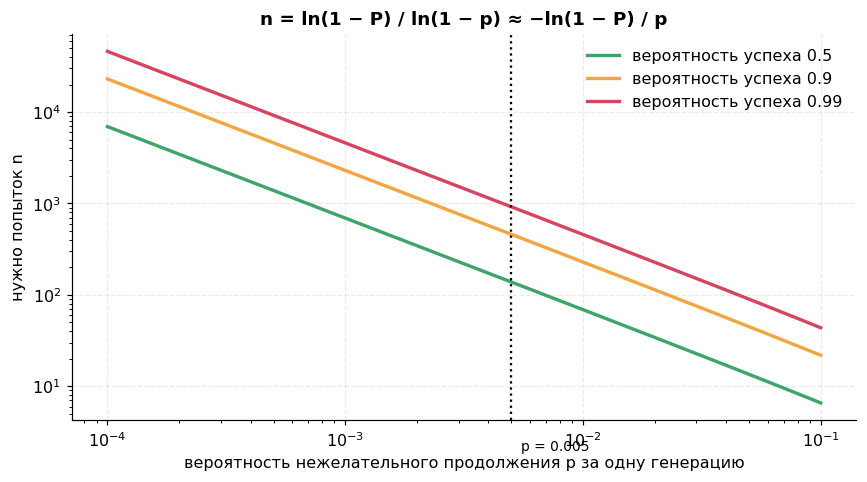

p = 0.001: до 0.5 — 693, до 0.9 — 2302, до 0.99 — 4603 попыток
p = 0.005: до 0.5 — 139, до 0.9 — 460, до 0.99 — 919 попыток
p = 0.02: до 0.5 — 35, до 0.9 — 114, до 0.99 — 228 попыток


In [ ]:
# Дополнительное задание: число попыток до заданной вероятности успеха как функция p
ps = np.logspace(-4, -1, 200)
fig, ax = plt.subplots(figsize=(8, 4.5))
for target, c in ((0.5, PALETTE["good"]), (0.9, PALETTE["linear"]), (0.99, PALETTE["bad"])):
    ax.loglog(ps, np.log(1 - target) / np.log(1 - ps), color=c, lw=2.2, label=f"вероятность успеха {target}")
ax.axvline(0.005, ls=":", color="k"); ax.text(0.0055, 2, "p = 0.005", fontsize=9)
ax.set_xlabel("вероятность нежелательного продолжения p за одну генерацию")
ax.set_ylabel("нужно попыток n"); ax.set_title("n = ln(1 − P) / ln(1 − p) ≈ −ln(1 − P) / p"); ax.legend()
plt.tight_layout(); plt.show()
for p in (0.001, 0.005, 0.02):
    print(f"p = {p}: до 0.5 — {int(np.ceil(np.log(0.5) / np.log(1 - p)))}, до 0.9 — "
          f"{int(np.ceil(np.log(0.1) / np.log(1 - p)))}, до 0.99 — {int(np.ceil(np.log(0.01) / np.log(1 - p)))} попыток")

**Вопрос H.** Модель отклоняет нежелательное продолжение в 99.5 % случаев. Сколько попыток нужно, чтобы получить его с вероятностью не ниже 0.9?

**Ответ H.** Вероятность хотя бы одного успеха за $n$ независимых попыток равна $1 - (1-p)^n$, где $p = 0.005$. Условие $1 - 0.995^n \ge 0.9$ даёт

$$n \ge \frac{\ln 0.1}{\ln 0.995} \approx 459.4 \;\Rightarrow\; n = \mathbf{460}.$$

Эксперимент подтверждает теорию: при $n = 360$ измерено 0.817 против теоретических 0.835 (разница — статистический шум 60 повторов). Для $p = 0.02$ хватает 114 попыток, для $p = 0.001$ нужно 2302 (см. дополнительный график).

**Вывод для методики оценки.** Одна проверка «модель отказала — значит, безопасна» ничего не доказывает: 99.5 % отказов при одной генерации означают, что за несколько сотен попыток нежелательный ответ будет получен почти наверняка, а автоматизированный перебор делает сотни попыток дёшево. Устойчивость нужно оценивать как **вероятность** нежелательного исхода по многим выборкам (и указывать метрику вида «успех хотя бы раз за $n$ попыток»), с фиксированными параметрами декодирования: температура сильно меняет хвост распределения — доля вероятности за 20-м рангом равна 0.009 при $\tau = 0.5$ и 0.259 при $\tau = 1.5$. Отсечение top-k и top-p помогает, если нежелательное продолжение лежит в хвосте, но бессильно, если его вероятность попадает внутрь сохраняемого набора.

**H.4. Расстояния в шаблоне чата.** Последовательность из 26 токенов. Среднее расстояние до точки генерации: системная инструкция — **22.0** токена, сообщение пользователя — 15.0, документ — 9.5, вставленный в документ фрагмент-«инъекция» — **4.5**. При сильном затухании по расстоянию ($m = 0.25$) относительный вес инъекции 0.325 против 0.004 у системной инструкции, в **80 раз** больше; при слабом ($m = 0.03$) — 0.874 против 0.517.

Главное: для модели шаблон чата — это **одна последовательность токенов**. Роли отмечены лишь несколькими специальными токенами, но внимание не имеет механизма привилегий: каждая позиция может смотреть на любую предыдущую, и вес определяется содержанием и расстоянием, а не тем, кто написал текст. Инструкция внутри документа технически ничем не отличается от системной, а находится **ближе** к точке генерации. Поэтому вставленный в контекст текст может переопределить исходные инструкции — это и есть архитектурная предпосылка инъекций в контекст (prompt injection), которую разбирают на следующей лекции.

## Отчёт (вариант 1: `SEED = 42`, `D_MODEL = 64`, `N_MAX = 12`, `D_CELL = 48`, τ = 0.5 / 1.0 / 1.5)

### Таблица 1. Токенизация (часть A)

| Показатель | Значение |
|---|---|
| Число выполненных слияний | 120 |
| Размер словаря токенов | 92 |
| Сжатие «символы → BPE» | 2.30× (2652 символа → 1152 токена) |
| Отношение «BPE → слова» | 3.49 токена на слово (1152 / 330) |
| Доля редких токенов (частота ≤ `RARE_THR` = 6) | 0.489 |

### Таблица 2. Затухание градиента (часть B)

| $\rho(W)$ или $f_t$ | Норма при $k=100$ | Горизонт до $10^{-6}$ |
|---|---|---|
| 0.9 | $4.8\cdot10^{-5}$ | 132 шага |
| 1.0 | 1.82 | не достигается (∞) |
| 1.2 | $1.5\cdot10^{8}$ (взрыв) | не достигается (∞) |
| $f_t = 0.99$ | 0.366 | 1375 шагов |

### Таблица 3. Масштабирование внимания (часть C), $n = 64$, максимум $\ln 64 = 4.159$

| $d_k$ | Энтропия с делителем | Энтропия без делителя |
|---|---|---|
| 8 | 3.686 | 2.040 |
| 64 | 3.684 | 0.586 |
| 256 | 3.684 | 0.264 |

### Таблица 4. Мини-трансформер (часть E), обучение на 2…12 парах

| Число пар в контексте | 2 | 4 | 8 | 12 | 16 | 20 |
|---|---|---|---|---|---|---|
| Точность вспоминания | 0.996 | 1.000 | 1.000 | 0.996 | 0.688 | 0.578 |

Финальное значение функции потерь: **0.0081** (среднее за 100 последних шагов).  Время обучения: **60 с**.
Масса внимания финального запроса на позиции нужного значения: **0.957**.

### Таблица 5. Линейное внимание (часть F)

| Показатель | Значение |
|---|---|
| Расхождение параллельной и рекуррентной форм | $2.4\cdot10^{-7}$ |
| Размер состояния, чисел | 272 ($16\times16 + 16$) |
| Качество чтения при 4 парах | 0.604 |
| Качество чтения при 256 парах | 0.085 |

### Таблица 6. Избирательная рекуррентность (часть G)

| Вариант ячейки | Точность | Комментарий |
|---|---|---|
| избирательные гейты | 1.000 | Гейт записи на позиции цели 0.498 против 0.188 в среднем |
| постоянное затухание | 0.070 | Выученное $a \approx 0.52$: горизонт ~7 шагов, цель забывается |
| случайное угадывание | 0.062 | теоретическое значение |

Доля каналов с гейтом сохранения выше 0.9: **0.191**.

### Таблица 7. Декодирование (часть H)

| Температура варианта | Энтропия, нат | $p_{\max}$ |
|---|---|---|
| 0.5 | 1.269 | 0.675 |
| 1.0 | 2.888 | 0.272 |
| 1.5 | 3.368 | 0.146 |

Число попыток для события с $p=0{,}005$ до вероятности 0,9: **460**.

### Выводы

1. **Токенизация — прямой рычаг стоимости внимания.** BPE сократил последовательность в 2.30 раза; при посимвольной токенизации стоимость внимания выросла бы в 5.3 раза. Цена — длинный хвост редких токенов: 48.9 % словаря встречаются не чаще 6 раз.
2. **Мультипликативная рекуррентность либо забывает, либо взрывается.** При $\rho = 0.9$ градиент на 100 шагах ослабевает до $4.8\cdot10^{-5}$ (горизонт 132 шага), при $\rho = 1.2$ вырастает до $1.5\cdot10^{8}$. Аддитивный путь с гейтом 0.99 сохраняет 0.366 и держит горизонт 1375 шагов.
3. **Делитель $\sqrt{d_k}$ необходим.** Без него энтропия внимания падает с 2.04 до 0.26 нат при росте $d_k$ с 8 до 256, softmax вырождается в one-hot и перестаёт пропускать градиент. С делителем энтропия стабильна: 3.68 нат при любом $d_k$.
4. **Внимание решает задачу точного вспоминания двумя слоями.** Мини-трансформер достиг точности 0.996–1.000 на длинах обучения; найдена индукционная схема: слой 1 переносит ключ в позицию значения (92.6 % внимания на предыдущий токен), слой 2 находит нужное значение (0.957 массы внимания). Обучаемая абсолютная кодировка не переносится на длинные последовательности: 0.688 и 0.578 на 16 и 20 парах.
5. **Линейное внимание меняет точность на память.** Состояние из 272 чисел не зависит от длины, но качество чтения падает с 1.000 при одной паре до 0.085 при 256. Сравняться с KV-кэшем на 4096 токенах состояние сможет только при $d = 8192$.
6. **Избирательность — ключ к управляемой памяти.** Ячейка с гейтами, зависящими от входа, решила задачу поиска символа после маркера на 100 %, ячейка с постоянным затуханием — на уровне угадывания (0.070 против 0.062).
7. **Устойчивость генерации — вероятностное свойство, а контекст не имеет границ привилегий.** Событие с вероятностью 0.005 за 460 попыток происходит с вероятностью 0.9; измерение совпало с теорией. В шаблоне чата вставленный фрагмент стоит в 4.5 токена от генерации против 22 у системной инструкции и при затухании $m = 0.25$ получает в 80 раз больший вес.

## Контрольные вопросы

**1. Почему стоимость внимания растёт как $O(n^2 d)$, а FFN — как $O(n d^2)$? При какой длине внимание доминирует?**
Внимание вычисляет матрицу $QK^\top$ размера $n \times n$, каждый элемент которой — скалярное произведение длины $d$: $n^2 d$ операций, и столько же на умножение весов на $V$. FFN применяется к каждой из $n$ позиций независимо и состоит из матриц $d \times 4d$ и $4d \times d$: около $8nd^2$ операций, линейно по $n$. Квадратичная часть внимания $2n^2 d$ сравнивается с FFN при $2n^2 d = 8nd^2$, то есть при $n = 4d$ (если учесть ещё проекции Q, K, V, O — порядок тот же, $n \sim$ несколько $d$). Для $d = 64$ из этой работы это около 256 токенов, для больших моделей с $d = 4096$ — около 16 тыс. токенов.

**2. Чем каузальная маска отличается от двунаправленного внимания при обучении и применении?**
При обучении каузальная маска позволяет за один проход учить предсказание **каждого** следующего токена по его префиксу: все $n$ задач обучаются параллельно без утечки ответа из будущего. Двунаправленное внимание видит весь контекст и подходит для задач понимания (классификация, заполнение пропусков, как в BERT), но не может напрямую генерировать текст. При применении каузальная модель генерирует слева направо, и благодаря маске представления прошлых токенов не меняются при добавлении новых, поэтому их ключи и значения можно кэшировать. У двунаправленной модели при добавлении токена пришлось бы пересчитывать всё.

**3. Почему RoPE позволяет расширять контекст после обучения, а обучаемая абсолютная кодировка — нет?**
RoPE — формула, определённая для любой позиции, а скалярное произведение зависит только от разности $t - s$ (проверено с точностью $10^{-13}$). Можно применить её к более длинным последовательностям и, при необходимости, сжать частоты вращения (позиционная интерполяция), чтобы новые расстояния попали в знакомый диапазон углов. Обучаемая кодировка — таблица векторов: для позиций за пределами обучения векторов нет или они не обучены, и интерполировать их неоткуда. В части E это видно по падению точности с 0.996 до 0.578 при выходе за обучающую длину.

**4. В чём вычислительная разница между обучением и генерацией и что кэшируется?**
При обучении вся последовательность известна, все позиции обрабатываются одновременно одним матричным проходом — вычисления хорошо параллелятся и упираются в арифметику. При генерации токены появляются по одному, каждый шаг — отдельный проход, упирающийся в пропускную способность памяти. Чтобы не пересчитывать прошлое, кэшируются **ключи и значения** (KV-кэш) всех прошлых токенов в каждом слое и каждой голове: новый токен считает только свои $q, k, v$ и смотрит на сохранённые. Кэш растёт линейно с длиной контекста — именно его и заменяет постоянное состояние линейного внимания.

**5. Как GQA и MQA уменьшают KV-кэш и чем приходится платить?**
В обычном многоголовом внимании у каждой из $H$ голов свои ключи и значения. MQA (multi-query) использует **одну** общую пару K, V на все головы запросов — кэш уменьшается в $H$ раз. GQA (grouped-query) делит головы на $G$ групп со своей парой K, V в каждой — кэш уменьшается в $H/G$ раз. Плата — потеря выразительности: разные головы вынуждены смотреть в одно и то же пространство ключей, что может немного снизить качество; GQA — компромисс между MQA (минимальный кэш) и полным MHA (максимальное качество).

**6. Почему линейное внимание проигрывает softmax-вниманию на задачах точного вспоминания?**
Softmax-внимание хранит **все** ключи и значения отдельно и может сфокусироваться на единственной нужной позиции (в части E — 0.957 массы на нужном значении). Линейное внимание сжимает всю историю в состояние фиксированного размера $d \times d$ как сумму внешних произведений: пары накладываются друг на друга, а неотрицательная функция $\varphi$ не даёт получить резкое распределение. Ёмкость ограничена примерно $d$ парами, дальше — интерференция (качество чтения 0.604 при 4 парах и 0.085 при 256 при $d = 16$).

**7. Что делает рекуррентность «избирательной» и почему это восстанавливает способность игнорировать контекст?**
Коэффициенты затухания $a$ и записи $b$ вычисляются **по текущему входу**, а не фиксированы. Поэтому модель на каждом шаге сама решает, записывать ли вход в состояние и сохранять ли то, что уже записано: на нерелевантных токенах $b$ мало (вход не записывается), на важных — велико; после записи $a \approx 1$ удерживает информацию. В части G гейт записи на целевом символе в 2.6 раза выше среднего, а постоянное затухание не справилось вовсе (0.070 против 1.000).

**8. Почему смесь экспертов требует балансирующей потери и что происходит без неё?**
Маршрутизатор в MoE направляет каждый токен к нескольким из многих экспертов. Без балансирующей потери возникает положительная обратная связь: эксперт, получивший чуть больше токенов в начале обучения, обучается лучше, маршрутизатор ему больше доверяет и отправляет ещё больше токенов. Происходит **коллапс маршрутизации**: несколько экспертов перегружены (и при ограниченной ёмкости часть токенов отбрасывается), остальные почти не учатся, и модель фактически теряет свою ёмкость. Балансирующая потеря штрафует неравномерное распределение нагрузки (обычно произведение доли токенов и средней вероятности маршрутизатора по экспертам) и выравнивает загрузку.

**9. Как связаны параметры декодирования и воспроизводимость оценки устойчивости?**
Вывод модели — случайная выборка, и её распределение определяется температурой, top-k, top-p и seed. От них сильно зависит хвост: доля вероятности за 20-м рангом равна 0.009 при $\tau = 0.5$ и 0.259 при $\tau = 1.5$. Одна и та же модель может выглядеть безопасной при жадном декодировании и небезопасной при $\tau = 1.5$. Поэтому в оценке нужно фиксировать и публиковать параметры декодирования и seed, проводить много выборок на каждый запрос и сообщать вероятности (например, долю успеха хотя бы раз за $n$ попыток), а не единичный результат.

**10. Почему шаблон чата не создаёт настоящей границы привилегий между системной инструкцией и содержимым документа?**
Шаблон — это только соглашение о разметке: роли обозначены несколькими специальными токенами, а всё содержимое склеивается в одну последовательность. Внимание обрабатывает все позиции одним механизмом; у модели нет аппаратно или программно защищённого канала для инструкций разработчика. Приоритет системной инструкции — лишь выученная статистическая склонность, которую текст в контексте может перевесить. Вставленный фрагмент к тому же находится ближе к точке генерации (4.5 токена против 22 в нашем шаблоне). Поэтому данные, пришедшие из документа, письма или веб-страницы, могут быть восприняты как инструкции — это и есть инъекция в контекст. Защита требует мер вне модели: разделения данных и инструкций на уровне системы, ограничения прав инструментов, фильтрации и проверки действий.

## Дополнительные задания

Выполнено: оценка числа попыток до заданной вероятности успеха как функции $p$ (ячейка после H.4).


- Добавьте в часть E третий слой и проверьте, меняется ли характер переноса на длины больше
  обучающих.
- Замените в части E обучаемую абсолютную кодировку на RoPE и повторите измерение точности для
  16 и 20 пар.
- Реализуйте в части F многоголовое линейное внимание и постройте зависимость качества чтения от
  числа голов при фиксированном общем размере состояния.
- Реализуйте слой смеси экспертов с балансирующей потерей и покажите, как меняется распределение
  нагрузки при её отключении.
- Постройте в части H оценку числа попыток до заданной вероятности успеха как функцию $p$ и
  обсудите, как это влияет на протокол тестирования.

## Чек-лист сдачи

- [ ] Заполнен паспорт работы, указан вариант и его параметры.
- [ ] Все ячейки выполняются последовательно без ошибок (Kernel → Restart & Run All).
- [ ] Реализованы все `TODO` в частях A–H.
- [ ] Заполнены таблицы 1–7 числами своего варианта.
- [ ] Даны ответы на вопросы A–H и контрольные вопросы 1–10.
- [ ] Сформулировано не менее пяти выводов со ссылками на измеренные значения.
- [ ] Все графики подписаны по-русски и читаемы.



## Литература

- Vaswani A. et al. Attention Is All You Need (2017): <https://arxiv.org/abs/1706.03762>
- Hochreiter S., Schmidhuber J. Long Short-Term Memory (1997):
  <https://direct.mit.edu/neco/article/9/8/1735/6109>
- Su J. et al. RoFormer: Enhanced Transformer with Rotary Position Embedding (2021):
  <https://arxiv.org/abs/2104.09864>
- Press O. et al. Train Short, Test Long: Attention with Linear Biases (ALiBi) (2021):
  <https://arxiv.org/abs/2108.12409>
- Katharopoulos A. et al. Transformers are RNNs: Fast Autoregressive Transformers with Linear
  Attention (2020): <https://arxiv.org/abs/2006.16236>
- Gu A., Dao T. Mamba: Linear-Time Sequence Modeling with Selective State Spaces (2023):
  <https://arxiv.org/abs/2312.00752>
- Ainslie J. et al. GQA: Training Generalized Multi-Query Transformer Checkpoints (2023):
  <https://arxiv.org/abs/2305.13245>
- Dao T. et al. FlashAttention: Fast and Memory-Efficient Exact Attention with IO-Awareness (2022):
  <https://arxiv.org/abs/2205.14135>
- Olsson C. et al. In-context Learning and Induction Heads (2022):
  <https://arxiv.org/abs/2209.11895>
- Holtzman A. et al. The Curious Case of Neural Text Degeneration (2019):
  <https://arxiv.org/abs/1904.09751>